# **ASU CHM 343 Physical Chemistry Lab '2' - Notebook**

***Determination of Thermochemical Properties of Fatty Acids and Sugars by Using Simulated Bomb Calorimetry Data***

September 23, 2025

**Sebastian Raymundo**, sraymun1@asu.edu

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sraymundo15/sraymundo15/blob/master/Calorimetry%20Lab/CHM343_Physical_Chemistry_Lab_2_Colab_Notebook_Sebastian_Raymundo.ipynb)


# **Abstract**

A computational estimate of enthalpies of formation (**Hf**) and combustion (**Hc**) was calculated using PM6 semi-empirical data from both ***MoleCalc.Cloud***<sup>[1]</sup> and ***ChemCompute GAMESS***<sup>[2]</sup>. This data was obtained for four simple chemical compounds: **Benzoic Acid** (C7H6O2), **Naphthalene** (C10H8), **Lauric Acid** (C12H24O2), and **β-d-Fructose** (C6H12O6). Bomb calorimetry data was obtained from a Parr Oxygen Bomb Combustion Calorimeter simulation hosted by Arizona State University<sup>[3]</sup>. Using the calorimetry data, the experimental enthalpies of formation were determined: for Benzoic Acid as **385.22 ± 16.15 kJ/mol**, for Naphthalene as **58.92 ± 51.88 kJ.mol**, for Lauric Acid as **-770.98 ± 72.71 kJ/mol**, and for β-d-Fructose as **-1291.01 ± 49.10 kJ/mol**. Additionally, the experimental enthalpies of combustion were calculated: for Benzoic Acid as **-3226.84 ± 16.12 kJ/mol**, for Naphthalene as **-5137.34 ± 51.86 kJ.mol**, for Lauric Acid as **-7381.10 ± 72.69 kJ/mol**, and for β-d-Fructose as **-2785.03 ± 49.09 kJ/mol**. All calculations were executed within this CoLab notebook using numpy and pandas.

# **Introduction**

# **Methods**
Benzoic Acid, Naphthalene, and Lauric Acid were analyzed with **MoleCalc.Cloud**<sup>[1]</sup> with the PM6 semi-empirical method in order to obtain computational enthalpy of formation data for the gas phases of each compound. β-d-Fructose was analyzed with **ChemCompute GAMESS**<sup>[2]</sup>, also using the PM6 method, because MoleCalc.Cloud was unable to analyze the compound. Literature values for each compound's enthalpy of sublimation, except β-d-Fructose, were obtained from the **NIST Webbook**<sup>[]</sup> website and used to arrive at a computational estimate of each compound's enthalpies of formation and combustion for the solid phase, calculated by using Hess's Law.

Next, bomb calorimetry data obtained from the **Bomb Calorimeter simulation**<sup>[3]</sup> hosted by [Arizona State University](https://www.asu.edu/) was uploaded to a public Github repo and read into this CoLab notebook for easier analysis, plotting and display. The simulated experimental data was obtained using the bomb calorimeter code 3655, matching the last four digits of my ASU ID as instructed in class announcements. The data was plotted and displayed to show the relationship between time and temperature for each compound, the change in temperature (**ΔT**) for each compound in the bomb calorimeter, and the slopes of the data points before and after the reaction took place. Using the values provided by the simulation website for heat of combustion for Benzoic Acid and the iron wire in the calorimeter, the calorimeter constant (**C_eq**) and its related error propagation for bomb calorimeter code 3655 were calculated. Estimated, minimum, and maximum thermodynamic estimates of the calorimeter constant were also calculated

Error analysis of the ΔT for each chemical compound was performed as preparation for further calculations. Then, each compound's enthalpies of combustion and formation were calculated by following Hess's law and the balanced chemical equations for the combustion of each compound. Finally, the computational and experimental enthalpies were compared to the literature values to validate the success or failure of the experiment and calculations, as well as the potential errors.

# **Setup Notebook Environment**

In [ ]:
# Primary Python Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# **Computational Data**

In [ ]:
# @title Calculation of Enthalpy of Formation (solid) for Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose
# Enthalpy of formation of Benzoic Acid (gas) and its uncertainty (from MoleCalc.Cloud)
Delta_Hf_BA_gas = -270.21 # kJ/mol
sigma_Delta_Hf_BA_gas = 0 # Assuming no uncertainty

# Enthalpy of sublimation of Benzoic Acid and its uncertainty (from NIST Webbook - Ginkel,Kruif, et al.)
Delta_H_sub_BA_lit = 93 # kJ/mol
sigma_Delta_H_sub_BA_lit = 4 # kJ/mol

# Calculate the enthalpy of formation of Benzoic Acid (solid)
Delta_Hf_BA_solid = Delta_H_sub_BA_lit - Delta_Hf_BA_gas

# Error Propagation for Delta_Hf_BA_solid
# Partial derivatives:
# d_Delta_Hf_BA_solid_d_Delta_Hf_BA_gas = 1
# d_Delta_Hf_BA_solid_d_Delta_H_sub_BA = -1

# Assuming uncertainties in Delta_Hf_BA_gas and Delta_H_sub_BA_lit are independent
sigma_Delta_Hf_BA_solid_squared = (1**2 * sigma_Delta_Hf_BA_gas**2 +
                                   (-1)**2 * sigma_Delta_H_sub_BA_lit**2)

sigma_Delta_Hf_BA_solid = math.sqrt(sigma_Delta_Hf_BA_solid_squared)

print(f'Benzoic Acid (solid, from literature sublimation value): Delta Hf = {Delta_Hf_BA_solid:.2f} +/- {sigma_Delta_Hf_BA_solid:.2f} kJ/mol')


# Enthalpy of formation of Naphthalene (gas) and its uncertainty (from MoleCalc.Cloud)
Delta_Hf_Naph_gas = 168.42 # kJ/mol
sigma_Delta_Hf_Naph_gas = 0 # Assuming no uncertainty

# Enthalpy of sublimation of Naphthalene and its uncertainty (from NIST Webbook - McEachern and Sandoval)
Delta_H_sub_Naph_lit = 64 # kJ/mol
sigma_Delta_H_sub_Naph_lit = 0.5 # kJ/mol

# Calculate the enthalpy of formation of Naphthalene (solid)
Delta_Hf_Naph_solid = Delta_Hf_Naph_gas - Delta_H_sub_Naph_lit

# Error Propagation for Delta_Hf_Naph_solid
# Partial derivatives:
# d_Delta_Hf_Naph_solid_d_Delta_Hf_Naph_gas = 1
# d_Delta_Hf_Naph_solid_d_Delta_H_sub_Naph_lit = -1

# Assuming uncertainties in Delta_Hf_Naph_gas and Delta_H_sub_Naph_lit are independent
sigma_Delta_Hf_Naph_solid_squared = (1**2 * sigma_Delta_Hf_Naph_gas**2 +
                                       (-1)**2 * sigma_Delta_H_sub_Naph_lit**2)

sigma_Delta_Hf_Naph_solid = math.sqrt(sigma_Delta_Hf_Naph_solid_squared)

print(f'Naphthalene (solid, from literature sublimation value): Delta Hf = {Delta_Hf_Naph_solid:.2f} +/- {sigma_Delta_Hf_Naph_solid:.2f} kJ/mol')


# Enthalpy of formation of Lauric Acid (gas) and its uncertainty (from MoleCalc.Cloud)
Delta_Hf_LA_gas = -591.48 # kJ/mol
sigma_Delta_Hf_LA_gas = 0 # Assuming no uncertainty

# Enthalpy of sublimation of Lauric Acid and its uncertainty (from NIST Webbook - Davies and Malpass)
Delta_H_sub_LA_lit = 140 # kJ/mol
sigma_Delta_H_sub_LA_lit = 3 # kJ/mol

# Calculate the enthalpy of formation of Lauric Acid (solid)
Delta_Hf_LA_solid = Delta_Hf_LA_gas - Delta_H_sub_LA_lit

# Error Propagation for Delta_Hf_LA_solid
# Partial derivatives:
# d_Delta_Hf_LA_solid_d_Delta_Hf_LA_gas = 1
# d_Delta_Hf_LA_solid_d_Delta_H_sub_LA_lit = -1

# Assuming uncertainties in Delta_Hf_LA_gas and Delta_H_sub_LA_lit are independent
sigma_Delta_Hf_LA_solid_squared = (1**2 * sigma_Delta_Hf_LA_gas**2 +
                                   (-1)**2 * sigma_Delta_H_sub_LA_lit**2)

sigma_Delta_Hf_LA_solid = math.sqrt(sigma_Delta_Hf_LA_solid_squared)

print(f'Lauric Acid (solid, from literature sublimation value): Delta Hf = {Delta_Hf_LA_solid:.2f} +/- {sigma_Delta_Hf_LA_solid:.2f} kJ/mol')

# Enthalpy of formation of β-d-Fructose (gas) and its uncertainty (from ChemCompute GAMESS)
Delta_Hf_BDF_gas = -277.54727 # kJ/mol
sigma_Delta_Hf_BDF_gas = 0 # Assuming no uncertainty

# Enthalpy of formation of β-d-Fructose (solid) and its uncertainty (directly from NIST Webbook as no literature sublimation value was available)
Delta_Hf_BDF_solid = -1265.6 # kJ/mol
sigma_Delta_Hf_BDF_solid = 0.46 # kJ/mol

print(f'β-d-Fructose (solid, literature value): Delta Hf = {Delta_Hf_BDF_solid:.2f} +/- {sigma_Delta_Hf_BDF_solid:.2f} kJ/mol')

Benzoic Acid (solid, from literature sublimation value): Delta Hf = 363.21 +/- 4.00 kJ/mol
Naphthalene (solid, from literature sublimation value): Delta Hf = 104.42 +/- 0.50 kJ/mol
Lauric Acid (solid, from literature sublimation value): Delta Hf = -731.48 +/- 3.00 kJ/mol
β-d-Fructose (solid, literature value): Delta Hf = -1265.60 +/- 0.46 kJ/mol


In [ ]:
# @title Calculation of Theoretical Enthalpy of Combustion for Benzoic Acid, Naphthalene, Lauric Acid, and β-d-Fructose
# Calculate the theoretical (thermodynamic) enthalpy of combustion using provided literature enthalpy of formation values

# Literature Enthalpies of Formation (kJ/mol)
Delta_Hf_CO2_g_computational = -354.73 # kJ/mol (from MoleCalc.Cloud)
sigma_Delta_Hf_CO2_g_computational = 0 # Assuming no uncertainty

Delta_Hf_H2O_g_computational = -227.19 # kJ/mol (from MoleCalc.Cloud)
sigma_Delta_Hf_H2O_g_computational = 0 # Assuming no uncertainty

Delta_Hf_O2_g_std = 0.0 # kJ/mol (Standard state of element)
sigma_Delta_Hf_O2_g_std = 0.0 # Assuming no uncertainty

# Enthalpy of vaporization of water (user provided)
Delta_H_vap_H2O = 40.65 # kJ/mol
sigma_Delta_H_vap_H2O = 0 # Assuming no uncertainty

# Convert H2O enthalpy of formation from gas to liquid phase
Delta_Hf_H2O_l_computational = Delta_Hf_H2O_g_computational - Delta_H_vap_H2O

# Error propagation for Delta_Hf_H2O_l_computational
# Assuming uncertainties in Delta_Hf_H2O_g_computational and Delta_H_vap_H2O are independent
sigma_Delta_Hf_H2O_l_computational_squared = (1**2 * sigma_Delta_Hf_H2O_g_computational**2 +
                                         (-1)**2 * sigma_Delta_H_vap_H2O**2)
sigma_Delta_Hf_H2O_l_computational = math.sqrt(sigma_Delta_Hf_H2O_l_computational_squared)


# Literature Enthalpy of Formation (solid) - Calculated from gas phase and sublimation in previous cell:
# Delta_Hf_BA_solid
# sigma_Delta_Hf_BA_solid
# Delta_Hf_Naph_solid
# sigma_Delta_Hf_Naph_solid
# Delta_Hf_LA_solid
# sigma_Delta_Hf_LA_solid
# Delta_Hf_BDF_solid
# sigma_Delta_Hf_BDF_solid

# Hess's Law: Delta_Hc = Sum(n * Delta_Hf_products) - Sum(m * Delta_Hf_reactants)

# Benzoic Acid (C7H6O2): C7H6O2 (s) + 7.5 O2(g) -> 7 CO2(g) + 3 H2O(l)
Delta_Hc_BA_calc = (7 * Delta_Hf_CO2_g_computational + 3 * Delta_Hf_H2O_l_computational) - (Delta_Hf_BA_solid + 7.5 * Delta_Hf_O2_g_std)

# Error Propagation for theoretical Delta Hc for Benzoic Acid
# Partial derivatives:
d_Delta_Hc_BA_calc_d_Delta_Hf_CO2_g_computational = 7
d_Delta_Hc_BA_calc_d_Delta_Hf_H2O_l_computational = 3
d_Delta_Hc_BA_calc_d_Delta_Hf_BA_solid = -1
d_Delta_Hc_BA_calc_d_Delta_Hf_O2_g_std = -7.5

# Assuming uncertainties are independent
sigma_Delta_Hc_BA_calc_squared = (d_Delta_Hc_BA_calc_d_Delta_Hf_CO2_g_computational**2 * sigma_Delta_Hf_CO2_g_computational**2 +
                                      d_Delta_Hc_BA_calc_d_Delta_Hf_H2O_l_computational**2 * sigma_Delta_Hf_H2O_l_computational**2 +
                                      d_Delta_Hc_BA_calc_d_Delta_Hf_BA_solid**2 * sigma_Delta_Hf_BA_solid**2 +
                                      d_Delta_Hc_BA_calc_d_Delta_Hf_O2_g_std**2 * sigma_Delta_Hf_O2_g_std**2)

sigma_Delta_Hc_BA_calc = math.sqrt(sigma_Delta_Hc_BA_calc_squared)

print(f'Benzoic Acid (theoretical, using computational values): Delta Hc = {Delta_Hc_BA_calc:.2f} +/- {sigma_Delta_Hc_BA_calc:.2f} kJ/mol')


# Naphthalene (C10H8): C10H8(s) + 12 O2(g) -> 10 CO2(g) + 4 H2O(l)
Delta_Hc_Naph_calc = (10 * Delta_Hf_CO2_g_computational + 4 * Delta_Hf_H2O_l_computational) - (Delta_Hf_Naph_solid + 12 * Delta_Hf_O2_g_std)

# Error Propagation for theoretical Delta Hc for Naphthalene (using user-provided lit values)
# Partial derivatives:
d_Delta_Hc_Naph_calc_d_Delta_Hf_CO2_g_computational = 10
d_Delta_Hc_Naph_calc_d_Delta_Hf_H2O_l_computational = 4
d_Delta_Hc_Naph_calc_d_Delta_Hf_Naph_solid = -1
d_Delta_Hc_Naph_calc_d_Delta_Hf_O2_g_std = -12

# Assuming uncertainties are independent
sigma_Delta_Hc_Naph_calc_squared = (d_Delta_Hc_Naph_calc_d_Delta_Hf_CO2_g_computational**2 * sigma_Delta_Hf_CO2_g_computational**2 +
                                      d_Delta_Hc_Naph_calc_d_Delta_Hf_H2O_l_computational**2 * sigma_Delta_Hf_H2O_l_computational**2 +
                                      d_Delta_Hc_Naph_calc_d_Delta_Hf_Naph_solid**2 * sigma_Delta_Hf_Naph_solid**2 +
                                      d_Delta_Hc_Naph_calc_d_Delta_Hf_O2_g_std**2 * sigma_Delta_Hf_O2_g_std**2)

sigma_Delta_Hc_Naph_calc = math.sqrt(sigma_Delta_Hc_Naph_calc_squared)

print(f'Naphthalene (theoretical, using computational values): Delta Hc = {Delta_Hc_Naph_calc:.2f} +/- {sigma_Delta_Hc_Naph_calc:.2f} kJ/mol')


# Lauric Acid (C12H24O2): C12H24O2(s) + 17 O2(g) -> 12 CO2(g) + 12 H2O(l)
Delta_Hc_LA_calc = (12* Delta_Hf_CO2_g_computational + 12 * Delta_Hf_H2O_l_computational) - (Delta_Hf_LA_solid + 17 * Delta_Hf_O2_g_std)

# Error Propagation for theoretical Delta Hc for Lauric Acid (using user-provided lit values)
# Partial derivatives:
d_Delta_Hc_LA_calc_d_Delta_Hf_CO2_g_computational = 12
d_Delta_Hc_LA_calc_d_Delta_Hf_H2O_l_computational = 12
d_Delta_Hc_LA_calc_d_Delta_Hf_LA_solid = -1
d_Delta_Hc_LA_calc_d_Delta_Hf_O2_g_std = -17

# Assuming uncertainties are independent
sigma_Delta_Hc_LA_calc_squared = (d_Delta_Hc_LA_calc_d_Delta_Hf_CO2_g_computational**2 * sigma_Delta_Hf_CO2_g_computational**2 +
                                      d_Delta_Hc_LA_calc_d_Delta_Hf_H2O_l_computational**2 * sigma_Delta_Hf_H2O_l_computational**2 +
                                      d_Delta_Hc_LA_calc_d_Delta_Hf_LA_solid**2 * sigma_Delta_Hf_LA_solid**2 +
                                      d_Delta_Hc_LA_calc_d_Delta_Hf_O2_g_std**2 * sigma_Delta_Hf_O2_g_std**2)

sigma_Delta_Hc_LA_calc = math.sqrt(sigma_Delta_Hc_LA_calc_squared)

print(f'Lauric Acid (theoretical, using computational values): Delta Hc = {Delta_Hc_LA_calc:.2f} +/- {sigma_Delta_Hc_LA_calc:.2f} kJ/mol')


# β-d-Fructose (C6H12O6): C6H12O6(s) + 6 O2(g) -> 6 CO2(g) + 6 H2O(l)
Delta_Hc_BDF_calc = (6 * Delta_Hf_CO2_g_computational + 6 * Delta_Hf_H2O_l_computational) - (Delta_Hf_BDF_solid + 6 * Delta_Hf_O2_g_std)

# Error Propagation for theoretical Delta Hc for β-d-Fructose
# Partial derivatives:
d_Delta_Hc_BDF_calc_d_Delta_Hf_CO2_g_computational = 6
d_Delta_Hc_BDF_calc_d_Delta_Hf_H2O_l_computational = 6
d_Delta_Hc_BDF_calc_d_Delta_Hf_BDF_solid = -1
d_Delta_Hc_BDF_calc_d_Delta_Hf_O2_g_std = -6

# Assuming uncertainties are independent
sigma_Delta_Hc_BDF_calc_squared = (d_Delta_Hc_BDF_calc_d_Delta_Hf_CO2_g_computational**2 * sigma_Delta_Hf_CO2_g_computational**2 +
                                      d_Delta_Hc_BDF_calc_d_Delta_Hf_H2O_l_computational**2 * sigma_Delta_Hf_H2O_l_computational**2 +
                                      d_Delta_Hc_BDF_calc_d_Delta_Hf_BDF_solid**2 * sigma_Delta_Hf_BDF_solid**2 +
                                      d_Delta_Hc_BDF_calc_d_Delta_Hf_O2_g_std**2 * sigma_Delta_Hf_O2_g_std**2)

sigma_Delta_Hc_BDF_calc = math.sqrt(sigma_Delta_Hc_BDF_calc_squared)

print(f'β-d-Fructose (theoretical, using computational values): Delta Hc = {Delta_Hc_BDF_calc:.2f} +/- {sigma_Delta_Hc_BDF_calc:.2f} kJ/mol')

Benzoic Acid (theoretical, using computational values): Delta Hc = -3649.84 +/- 4.00 kJ/mol
Naphthalene (theoretical, using computational values): Delta Hc = -4723.08 +/- 0.50 kJ/mol
Lauric Acid (theoretical, using computational values): Delta Hc = -6739.36 +/- 3.00 kJ/mol
β-d-Fructose (theoretical, using computational values): Delta Hc = -2469.82 +/- 0.46 kJ/mol


In [ ]:
# @title Summary of Calculated Enthalpy Values
# Create a table to summarize the calculated enthalpy values

data = {
    'Substance': ['Benzoic Acid', 'Naphthalene', 'Lauric Acid', 'β-d-Fructose'],
    'Delta Hf (Gas, kJ/mol) (MoleCalc.Cloud/ChemCompute)': [
        f'{Delta_Hf_BA_gas:.2f} +/- {sigma_Delta_Hf_BA_gas:.2f} (PM6, semi-empirical method)',
        f'{Delta_Hf_Naph_gas:.2f} +/- {sigma_Delta_Hf_Naph_gas:.2f} (PM6, semi-empirical method)',
        f'{Delta_Hf_LA_gas:.2f} +/- {sigma_Delta_Hf_LA_gas:.2f} (PM6, semi-empirical method)',
        f'{Delta_Hf_BDF_gas:.2f} +/- {sigma_Delta_Hf_BDF_gas:.2f} (PM6, semi-empirical method)'
    ],
    'Enthalpy of Sublimation (NIST WebBook)': [
        f'{Delta_H_sub_BA_lit:.2f} +/- {sigma_Delta_H_sub_BA_lit:.2f}',
        f'{Delta_H_sub_Naph_lit:.2f} +/- {sigma_Delta_H_sub_Naph_lit:.2f}',
        f'{Delta_H_sub_LA_lit:.2f} +/- {sigma_Delta_H_sub_LA_lit:.2f}',
        'No information available'
    ],
    'Computational Delta Hf (Solid, kJ/mol)': [
        f'{Delta_Hf_BA_solid:.2f} +/- {sigma_Delta_Hf_BA_solid:.2f}',
        f'{Delta_Hf_Naph_solid:.2f} +/- {sigma_Delta_Hf_Naph_solid:.2f}',
        f'{Delta_Hf_LA_solid:.2f} +/- {sigma_Delta_Hf_LA_solid:.2f}',
        f'{Delta_Hf_BDF_solid:.2f} +/- {sigma_Delta_Hf_BDF_solid:.2f}'
    ],
    'Computational Delta Hc (Solid, kJ/mol)': [
        f'{Delta_Hc_BA_calc:.2f} +/- {sigma_Delta_Hc_BA_calc:.2f}',
        f'{Delta_Hc_Naph_calc:.2f} +/- {sigma_Delta_Hc_Naph_calc:.2f}',
        f'{Delta_Hc_LA_calc:.2f} +/- {sigma_Delta_Hc_LA_calc:.2f}',
        f'{Delta_Hc_BDF_calc:.2f} +/- {sigma_Delta_Hc_BDF_calc:.2f}'
    ]
}

df_enthalpy_summary = pd.DataFrame(data)

# Apply some styling to the DataFrame
styled_df = df_enthalpy_summary.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', 'steelblue'), ('color', 'white')]}])

display(styled_df.hide(axis='index'))

# Create a separate table for CO2, H2O, and O2 literature values
data_products = {
    'Substance': ['Carbon Dioxide', 'Water', 'Oxygen'],
    'Phase': ['gas', 'gas', 'gas'],
    'Delta Hf (kJ/mol) (MoleCalc.Cloud PM6)': [
        f'{Delta_Hf_CO2_g_computational:.2f} +/- {sigma_Delta_Hf_CO2_g_computational:.2f}',
        f'{Delta_Hf_H2O_g_computational:.2f} +/- {sigma_Delta_Hf_H2O_g_computational:.2f}',
        f'{Delta_Hf_O2_g_std:.2f} +/- {sigma_Delta_Hf_O2_g_std:.2f}'
    ]
}

df_products_summary = pd.DataFrame(data_products)

print ("")

display(df_products_summary.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', 'steelblue'), ('color', 'white')]}])\
        .hide(axis='index'))

Substance,"Delta Hf (Gas, kJ/mol) (MoleCalc.Cloud/ChemCompute)",Enthalpy of Sublimation (NIST WebBook),"Computational Delta Hf (Solid, kJ/mol)","Computational Delta Hc (Solid, kJ/mol)"
Benzoic Acid,"-270.21 +/- 0.00 (PM6, semi-empirical method)",93.00 +/- 4.00,363.21 +/- 4.00,-3649.84 +/- 4.00
Naphthalene,"168.42 +/- 0.00 (PM6, semi-empirical method)",64.00 +/- 0.50,104.42 +/- 0.50,-4723.08 +/- 0.50
Lauric Acid,"-591.48 +/- 0.00 (PM6, semi-empirical method)",140.00 +/- 3.00,-731.48 +/- 3.00,-6739.36 +/- 3.00
β-d-Fructose,"-277.55 +/- 0.00 (PM6, semi-empirical method)",No information available,-1265.60 +/- 0.46,-2469.82 +/- 0.46


Substance,Phase,Delta Hf (kJ/mol) (MoleCalc.Cloud PM6)
Carbon Dioxide,gas,-354.73 +/- 0.00
Water,gas,-227.19 +/- 0.00
Oxygen,gas,0.00 +/- 0.00


# **Calorimetry Data Analysis and Results**

---



This is simulation data obtained using the Calorimeter Code 3655 and uploaded to my public GitHub repo.

In [ ]:
# Read in Bomb Cal Simulated Data

df_BenzoicAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_benzoic_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_Naphthalene_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_naphthalene_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_LauricAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_lauric_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_b_d_Fructose_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_%CE%B2-d-fructose_cc3655.csv', sep = "," , header=11, skiprows=[11])

In [ ]:
# @title
url = 'https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_benzoic_acid_cc3655.csv'

# Fetch the content of the URL
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes
file_content = response.text

# Split the content into lines and find the data start line
lines = file_content.splitlines()
header_lines = []
data_start_row = 0
for i, line in enumerate(lines):
    header_lines.append(line)
    if line.startswith("===="):
        data_start_row = i + 1
        break

# Read the data using pandas from the identified row
#df_ba = pd.read_csv(url, sep=",", header=data_start_row, skiprows=data_start_row)
df_ba_temp = pd.read_csv(url, header=data_start_row)
df_ba_temp = df_ba_temp.add_prefix('Benzoic_Acid_')


# Extract specific header information: Calorimeter Code
calorimeter_code = "N/A" # Default value
for line in header_lines:
    if "Parr #" in line:
        calorimeter_code = line.split('#')[1].strip()
        break
print(f"Calorimeter Code: {calorimeter_code}")

# Extract specific header information: Sample Name
sample_name = "N/A" # Default value
for line in header_lines:
    if "Sample Name" in line:
        sample_name = line.split(',')[1].strip()
        break
print(f"Sample Name: {sample_name}")

# Extract specific header information: Formula
formula = "N/A" # Default value
for line in header_lines:
    if "Formula" in line:
        formula = line.split(',')[1].strip()
        break
print(f"Formula: {formula}")

# Extract specific header information: Molecular Weight
mol_wt = "N/A" # Default value
for line in header_lines:
    if "Molecular Weight" in line:
        mol_wt = float(line.split(',')[1].strip())
        break
print(f"Molecular Weight (g/mol): {mol_wt}")

# Extract specific header information: Sample Mass
sample_mass = "N/A" # Default value
for line in header_lines:
    if "Sample Weight (g)" in line:
        sample_mass = float(line.split(',')[1].strip())
        break
print(f"Sample Mass: {sample_mass}")

# Extract specific header information: Water Temp (C)
water_temp = "N/A" # Default value
for line in header_lines:
    if "Water Temp" in line:
        water_temp = float(line.split(',')[1].strip())
        break
print(f"Water Temp (C): {water_temp}")

# Extract specific header information: Lab (Room) Temp (C)
lab_temp = "N/A" # Default value
for line in header_lines:
    if "Room Temp" in line:
        lab_temp = float(line.split(',')[1].strip())
        break
print(f"Lab (Room) Temp (C): {lab_temp}")

# Extract specific header information: Water Volume (L)
water_vol = "N/A" # Default value
for line in header_lines:
    if "Water Volume" in line:
        water_vol = float(line.split(',')[1].strip())
        break
print(f"Water Volume (L): {water_vol}")

# Extract specific header information: Ignition Wire Mass Initial
wire_mass_initial = "N/A" # Default value
for line in header_lines:
    if "Wire Before (g)" in line:
        wire_mass_initial = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Initial: {wire_mass_initial}")

# Extract specific header information: Ignition Wire Mass Final
wire_mass_final = "N/A" # Default value
for line in header_lines:
    if "Wire After (g)" in line:
        wire_mass_final = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Final: {wire_mass_final}")



url = 'https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_naphthalene_cc3655.csv'

# Fetch the content of the URL
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes
file_content = response.text

# Split the content into lines and find the data start line
lines = file_content.splitlines()
header_lines = []
data_start_row = 0
for i, line in enumerate(lines):
    header_lines.append(line)
    if line.startswith("===="):
        data_start_row = i + 1
        break

# Read the data using pandas from the identified row
#df_ba = pd.read_csv(url, sep=",", header=data_start_row, skiprows=data_start_row)
df_na_temp = pd.read_csv(url, header=data_start_row)
df_na_temp = df_na_temp.add_prefix('Naphthalene_')

# Extract specific header information: Calorimeter Code
calorimeter_code = "N/A" # Default value
for line in header_lines:
    if "Parr #" in line:
        calorimeter_code = line.split('#')[1].strip()
        break
print(f"\nCalorimeter Code: {calorimeter_code}")

# Extract specific header information: Sample Name
sample_name = "N/A" # Default value
for line in header_lines:
    if "Sample Name" in line:
        sample_name = line.split(',')[1].strip()
        break
print(f"Sample Name: {sample_name}")

# Extract specific header information: Formula
formula = "N/A" # Default value
for line in header_lines:
    if "Formula" in line:
        formula = line.split(',')[1].strip()
        break
print(f"Formula: {formula}")

# Extract specific header information: Molecular Weight
mol_wt = "N/A" # Default value
for line in header_lines:
    if "Molecular Weight" in line:
        mol_wt = float(line.split(',')[1].strip())
        break
print(f"Molecular Weight (g/mol): {mol_wt}")

# Extract specific header information: Sample Mass
sample_mass = "N/A" # Default value
for line in header_lines:
    if "Sample Weight (g)" in line:
        sample_mass = float(line.split(',')[1].strip())
        break
print(f"Sample Mass: {sample_mass}")

# Extract specific header information: Water Temp (C)
water_temp = "N/A" # Default value
for line in header_lines:
    if "Water Temp" in line:
        water_temp = float(line.split(',')[1].strip())
        break
print(f"Water Temp (C): {water_temp}")

# Extract specific header information: Lab (Room) Temp (C)
lab_temp = "N/A" # Default value
for line in header_lines:
    if "Room Temp" in line:
        lab_temp = float(line.split(',')[1].strip())
        break
print(f"Lab (Room) Temp (C): {lab_temp}")

# Extract specific header information: Water Volume (L)
water_vol = "N/A" # Default value
for line in header_lines:
    if "Water Volume" in line:
        water_vol = float(line.split(',')[1].strip())
        break
print(f"Water Volume (L): {water_vol}")

# Extract specific header information: Ignition Wire Mass Initial
wire_mass_initial = "N/A" # Default value
for line in header_lines:
    if "Wire Before (g)" in line:
        wire_mass_initial = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Initial: {wire_mass_initial}")

# Extract specific header information: Ignition Wire Mass Final
wire_mass_final = "N/A" # Default value
for line in header_lines:
    if "Wire After (g)" in line:
        wire_mass_final = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Final: {wire_mass_final}")


url = 'https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_lauric_acid_cc3655.csv'

# Fetch the content of the URL
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes
file_content = response.text

# Split the content into lines and find the data start line
lines = file_content.splitlines()
header_lines = []
data_start_row = 0
for i, line in enumerate(lines):
    header_lines.append(line)
    if line.startswith("===="):
        data_start_row = i + 1
        break

# Read the data using pandas from the identified row
#df_ba = pd.read_csv(url, sep=",", header=data_start_row, skiprows=data_start_row)
df_ma_temp = pd.read_csv(url, header=data_start_row)
df_ma_temp = df_ma_temp.add_prefix('Lauric_Acid_')

# Extract specific header information: Calorimeter Code
calorimeter_code = "N/A" # Default value
for line in header_lines:
    if "Parr #" in line:
        calorimeter_code = line.split('#')[1].strip()
        break
print(f"\nCalorimeter Code: {calorimeter_code}")

# Extract specific header information: Sample Name
sample_name = "N/A" # Default value
for line in header_lines:
    if "Sample Name" in line:
        sample_name = line.split(',')[1].strip()
        break
print(f"Sample Name: {sample_name}")

# Extract specific header information: Formula
formula = "N/A" # Default value
for line in header_lines:
    if "Formula" in line:
        formula = line.split(',')[1].strip()
        break
print(f"Formula: {formula}")

# Extract specific header information: Molecular Weight
mol_wt = "N/A" # Default value
for line in header_lines:
    if "Molecular Weight" in line:
        mol_wt = float(line.split(',')[1].strip())
        break
print(f"Molecular Weight (g/mol): {mol_wt}")

# Extract specific header information: Sample Mass
sample_mass = "N/A" # Default value
for line in header_lines:
    if "Sample Weight (g)" in line:
        sample_mass = float(line.split(',')[1].strip())
        break
print(f"Sample Mass: {sample_mass}")

# Extract specific header information: Water Temp (C)
water_temp = "N/A" # Default value
for line in header_lines:
    if "Water Temp" in line:
        water_temp = float(line.split(',')[1].strip())
        break
print(f"Water Temp (C): {water_temp}")

# Extract specific header information: Lab (Room) Temp (C)
lab_temp = "N/A" # Default value
for line in header_lines:
    if "Room Temp" in line:
        lab_temp = float(line.split(',')[1].strip())
        break
print(f"Lab (Room) Temp (C): {lab_temp}")

# Extract specific header information: Water Volume (L)
water_vol = "N/A" # Default value
for line in header_lines:
    if "Water Volume" in line:
        water_vol = float(line.split(',')[1].strip())
        break
print(f"Water Volume (L): {water_vol}")

# Extract specific header information: Ignition Wire Mass Initial
wire_mass_initial = "N/A" # Default value
for line in header_lines:
    if "Wire Before (g)" in line:
        wire_mass_initial = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Initial: {wire_mass_initial}")

# Extract specific header information: Ignition Wire Mass Final
wire_mass_final = "N/A" # Default value
for line in header_lines:
    if "Wire After (g)" in line:
        wire_mass_final = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Final: {wire_mass_final}")


url = 'https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_%CE%B2-d-fructose_cc3655.csv'

# Fetch the content of the URL
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes
file_content = response.text

# Split the content into lines and find the data start line
lines = file_content.splitlines()
header_lines = []
data_start_row = 0
for i, line in enumerate(lines):
    header_lines.append(line)
    if line.startswith("===="):
        data_start_row = i + 1
        break

# Read the data using pandas from the identified row
#df_ba = pd.read_csv(url, sep=",", header=data_start_row, skiprows=data_start_row)
df_ga_temp = pd.read_csv(url, header=data_start_row)
df_ga_temp = df_ga_temp.add_prefix('β-d-Fructose_')


# Extract specific header information: Calorimeter Code
calorimeter_code = "N/A" # Default value
for line in header_lines:
    if "Parr #" in line:
        calorimeter_code = line.split('#')[1].strip()
        break
print(f"\nCalorimeter Code: {calorimeter_code}")

# Extract specific header information: Sample Name
sample_name = "N/A" # Default value
for line in header_lines:
    if "Sample Name" in line:
        sample_name = line.split(',')[1].strip()
        break
print(f"Sample Name: {sample_name}")

# Extract specific header information: Formula
formula = "N/A" # Default value
for line in header_lines:
    if "Formula" in line:
        formula = line.split(',')[1].strip()
        break
print(f"Formula: {formula}")

# Extract specific header information: Molecular Weight
mol_wt = "N/A" # Default value
for line in header_lines:
    if "Molecular Weight" in line:
        mol_wt = float(line.split(',')[1].strip())
        break
print(f"Molecular Weight (g/mol): {mol_wt}")

# Extract specific header information: Sample Mass
sample_mass = "N/A" # Default value
for line in header_lines:
    if "Sample Weight (g)" in line:
        sample_mass = float(line.split(',')[1].strip())
        break
print(f"Sample Mass: {sample_mass}")

# Extract specific header information: Water Temp (C)
water_temp = "N/A" # Default value
for line in header_lines:
    if "Water Temp" in line:
        water_temp = float(line.split(',')[1].strip())
        break
print(f"Water Temp (C): {water_temp}")

# Extract specific header information: Lab (Room) Temp (C)
lab_temp = "N/A" # Default value
for line in header_lines:
    if "Room Temp" in line:
        lab_temp = float(line.split(',')[1].strip())
        break
print(f"Lab (Room) Temp (C): {lab_temp}")

# Extract specific header information: Water Volume (L)
water_vol = "N/A" # Default value
for line in header_lines:
    if "Water Volume" in line:
        water_vol = float(line.split(',')[1].strip())
        break
print(f"Water Volume (L): {water_vol}")

# Extract specific header information: Ignition Wire Mass Initial
wire_mass_initial = "N/A" # Default value
for line in header_lines:
    if "Wire Before (g)" in line:
        wire_mass_initial = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Initial: {wire_mass_initial}")

# Extract specific header information: Ignition Wire Mass Final
wire_mass_final = "N/A" # Default value
for line in header_lines:
    if "Wire After (g)" in line:
        wire_mass_final = float(line.split(',')[1].strip())
        break
print(f"Ignition Wire Mass Final: {wire_mass_final}")


# Display the dataframes side-by-side
combined_df = pd.concat([df_ba_temp.head(30), df_na_temp.head(30), df_ma_temp.head(30), df_ga_temp.head(30)], axis=1)
display(combined_df)

Calorimeter Code: 3655
Sample Name: Benzoic Acid
Formula: C7H6O2
Molecular Weight (g/mol): 122.113
Sample Mass: 1.973
Water Temp (C): 24.98
Lab (Room) Temp (C): 24.98
Water Volume (L): 2.0
Ignition Wire Mass Initial: 0.024
Ignition Wire Mass Final: 0.018

Calorimeter Code: 3655
Sample Name: Naphthalene
Formula: C10H8
Molecular Weight (g/mol): 128.174
Sample Mass: 1.9483
Water Temp (C): 22.98
Lab (Room) Temp (C): 22.98
Water Volume (L): 2.0
Ignition Wire Mass Initial: 0.03
Ignition Wire Mass Final: 0.025

Calorimeter Code: 3655
Sample Name: Lauric Acid
Formula: C12H24O2
Molecular Weight (g/mol): 200.311
Sample Mass: 1.9233
Water Temp (C): 24.38
Lab (Room) Temp (C): 24.38
Water Volume (L): 2.0
Ignition Wire Mass Initial: 0.024
Ignition Wire Mass Final: 0.017

Calorimeter Code: 3655
Sample Name: β-D-Fructose
Formula: C6H12O6
Molecular Weight (g/mol): 180.126
Sample Mass: 1.9685
Water Temp (C): 25.58
Lab (Room) Temp (C): 25.58
Water Volume (L): 2.0
Ignition Wire Mass Initial: 0.025
Ignitio

,Benzoic_Acid_Time (s),Benzoic_Acid_Temperature (C),Naphthalene_Time (s),Naphthalene_Temperature (C),Lauric_Acid_Time (s),Lauric_Acid_Temperature (C),β-d-Fructose_Time (s),β-d-Fructose_Temperature (C)
0,0.0,24.98,0.0,22.98,0.0,24.38,0.0,25.58
1,30.0,24.98,30.0,23.00,30.0,24.38,30.0,25.56
2,60.0,24.97,60.0,23.00,60.0,24.37,60.0,25.58
3,90.0,24.97,90.0,22.99,90.0,24.38,90.0,25.56
4,120.0,24.99,120.0,22.98,120.0,24.39,120.0,25.60
5,150.0,24.99,150.0,22.98,150.0,24.37,150.0,25.60
6,180.0,24.98,180.0,22.98,180.0,24.40,180.0,25.57
7,210.0,24.99,210.0,22.96,210.0,24.40,210.0,25.57
8,240.0,24.96,240.0,22.96,240.0,24.39,240.0,25.57
9,270.0,24.97,270.0,22.98,270.0,24.37,270.0,25.57


# Plotting and Analysis of Each Substance for Calorimeter Code 3655

Substances selected: Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose

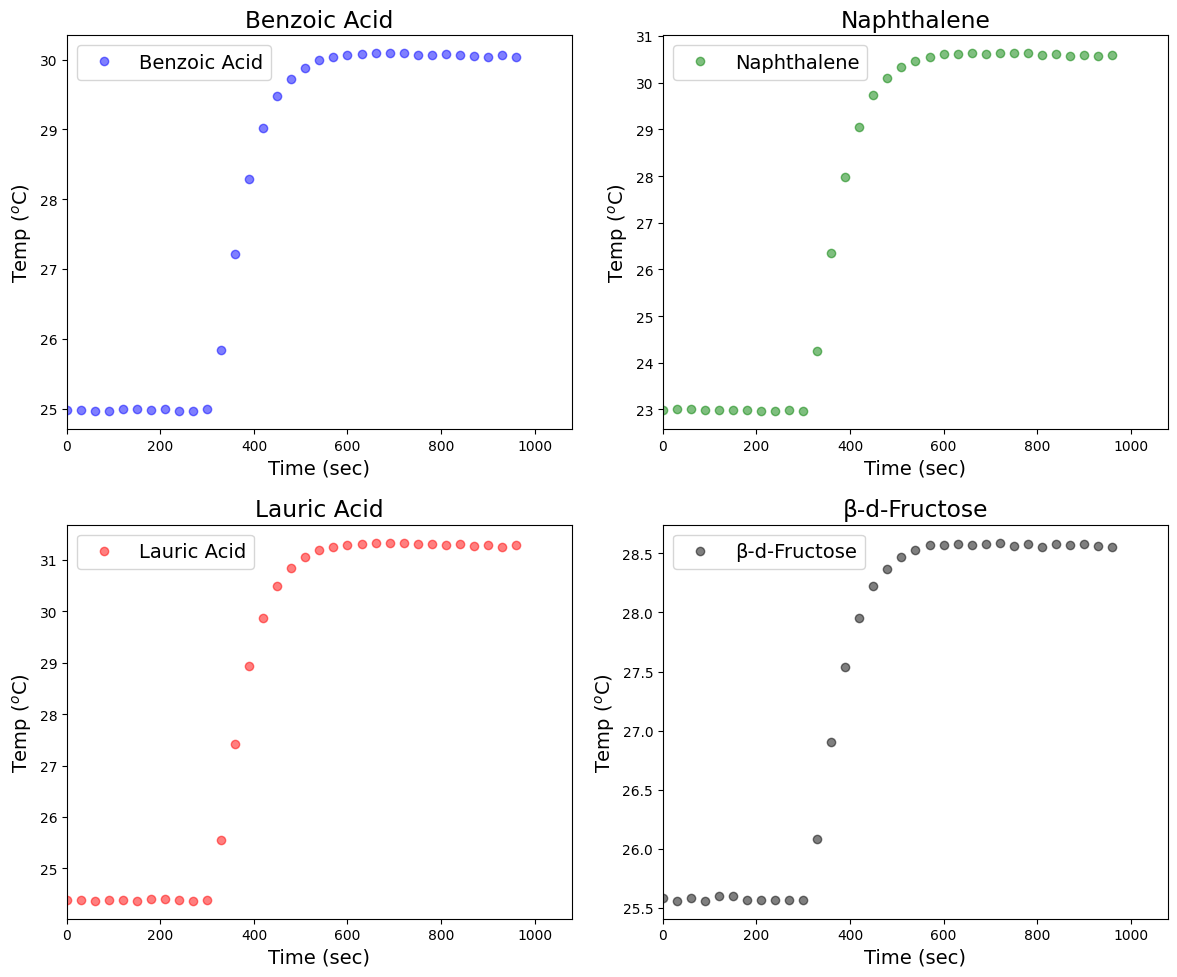

In [ ]:
#@title Plots for Benzoic Acid, Naphthalene, Lauric Acid, and β-d-Fructose
# Initialize matplotlib subplot layout
fig, axes = plt.subplots(2,2, figsize=(12, 10))

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
axes[0,0].plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')
axes[0,0].set_xlim(0, 1080)
axes[0,0].set_xlabel("Time (sec)", fontsize=14)
axes[0,0].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[0,0].legend()

axes[0,1].plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')
axes[0,1].set_xlim(0, 1080)
axes[0,1].set_xlabel("Time (sec)", fontsize=14)
axes[0,1].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[0,1].legend()

axes[1,0].plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Lauric Acid')
axes[1,0].set_xlim(0, 1080)
axes[1,0].set_xlabel("Time (sec)", fontsize=14)
axes[1,0].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[1,0].legend()

axes[1,1].plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')
axes[1,1].set_xlim(0, 1080)
axes[1,1].set_xlabel("Time (sec)", fontsize=14)
axes[1,1].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[1,1].legend()

# Add titles to the plots
axes[0,0].set_title('Benzoic Acid')
axes[0,1].set_title('Naphthalene')
axes[1,0].set_title('Lauric Acid')
axes[1,1].set_title('β-d-Fructose')

# Display the plots for easy view (tightly but without losing information)
plt.tight_layout()
plt.show()

In [ ]:
#@title Determine ΔT for Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose
# Define number of points to consider
Number_Points = 10

# Linear Extrapolation of starting and ending
# Benzoic Acid
Bomb_Cal_BA_Initial = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.start:df_BenzoicAcid_3655.index.start+Number_Points]
Bomb_Cal_BA_Final = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.stop-1-Number_Points:df_BenzoicAcid_3655.index.stop-1]

# Naphthalene
Bomb_Cal_Naph_Initial = df_Naphthalene_3655[df_Naphthalene_3655.index.start:df_Naphthalene_3655.index.start+Number_Points]
Bomb_Cal_Naph_Final = df_Naphthalene_3655[df_Naphthalene_3655.index.stop-1-Number_Points:df_Naphthalene_3655.index.stop-1]

# Lauric Acid
Bomb_Cal_LA_Initial = df_LauricAcid_3655[df_LauricAcid_3655.index.start:df_LauricAcid_3655.index.start+Number_Points]
Bomb_Cal_LA_Final = df_LauricAcid_3655[df_LauricAcid_3655.index.stop-1-Number_Points:df_LauricAcid_3655.index.stop-1]

# β-d-Fructose
Bomb_Cal_BDF_Initial = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.start:df_b_d_Fructose_3655.index.start+Number_Points]
Bomb_Cal_BDF_Final = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.stop-1-Number_Points:df_b_d_Fructose_3655.index.stop-1]

# Linear fits for initial and final data points including export of covariance matrices for uncertainty and error propagation calculations
# Benzoic Acid
p_BA_initial, cov_BA_initial = np.polyfit(Bomb_Cal_BA_Initial['Time (s)'], Bomb_Cal_BA_Initial['Temperature (C)'], deg=1, cov=True)
mi_BA, bi_BA = p_BA_initial
sigma_mi_BA, sigma_bi_BA = np.sqrt(np.diag(cov_BA_initial))
p_BA_final, cov_BA_final = np.polyfit(Bomb_Cal_BA_Final['Time (s)'], Bomb_Cal_BA_Final['Temperature (C)'], deg=1, cov=True)
mf_BA, bf_BA = p_BA_final
sigma_mf_BA, sigma_bf_BA = np.sqrt(np.diag(cov_BA_final))

# Naphthalene
p_Naph_initial, cov_Naph_initial = np.polyfit(Bomb_Cal_Naph_Initial['Time (s)'], Bomb_Cal_Naph_Initial['Temperature (C)'], deg=1, cov=True)
mi_Naph, bi_Naph = p_Naph_initial
sigma_mi_Naph, sigma_bi_Naph = np.sqrt(np.diag(cov_Naph_initial))
p_Naph_final, cov_Naph_final = np.polyfit(Bomb_Cal_Naph_Final['Time (s)'], Bomb_Cal_Naph_Final['Temperature (C)'], deg=1, cov=True)
mf_Naph, bf_Naph = p_Naph_final
sigma_mf_Naph, sigma_bf_Naph = np.sqrt(np.diag(cov_Naph_final))

# Lauric Acid
p_LA_initial, cov_LA_initial = np.polyfit(Bomb_Cal_LA_Initial['Time (s)'], Bomb_Cal_LA_Initial['Temperature (C)'], deg=1, cov=True)
mi_LA, bi_LA = p_LA_initial
sigma_mi_LA, sigma_bi_LA = np.sqrt(np.diag(cov_LA_initial))
p_LA_final, cov_LA_final = np.polyfit(Bomb_Cal_LA_Final['Time (s)'], Bomb_Cal_LA_Final['Temperature (C)'], deg=1, cov=True)
mf_LA, bf_LA = p_LA_final
sigma_mf_LA, sigma_bf_LA = np.sqrt(np.diag(cov_LA_final))

# β-d-Fructose
p_BDF_initial, cov_BDF_initial = np.polyfit(Bomb_Cal_BDF_Initial['Time (s)'], Bomb_Cal_BDF_Initial['Temperature (C)'], deg=1, cov=True)
mi_BDF, bi_BDF = p_BDF_initial
sigma_mi_BDF, sigma_bi_BDF = np.sqrt(np.diag(cov_BDF_initial))
p_BDF_final, cov_BDF_final = np.polyfit(Bomb_Cal_BDF_Final['Time (s)'], Bomb_Cal_BDF_Final['Temperature (C)'], deg=1, cov=True)
mf_BDF, bf_BDF = p_BDF_final
sigma_mf_BDF, sigma_bf_BDF = np.sqrt(np.diag(cov_BDF_final))

# Estimate Delta T from linear extrapolations
guess_temp = 375

dt_BA = ((bf_BA + mf_BA * guess_temp) - (bi_BA + mi_BA * guess_temp))
dt_Naph = ((bf_Naph + mf_Naph * guess_temp) - (bi_Naph + mi_Naph * guess_temp))
dt_LA = ((bf_LA + mf_LA * guess_temp) - (bi_LA + mi_LA * guess_temp))
dt_BDF = ((bf_BDF + mf_BDF * guess_temp) - (bi_BDF + mi_BDF * guess_temp))

# Estimate Delta T from max/min
dt_BA_est = df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min()
dt_Naph_est = df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min()
dt_LA_est = df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min()
dt_BDF_est = df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500

dt_BA_min = ((bf_BA + mf_BA * guess_tmin) - (bi_BA + mi_BA * guess_tmin))
dt_BA_max = ((bf_BA + mf_BA * guess_tmax) - (bi_BA + mi_BA * guess_tmax))

dt_Naph_min = ((bf_Naph + mf_Naph * guess_tmin) - (bi_Naph + mi_Naph * guess_tmin))
dt_Naph_max = ((bf_Naph + mf_Naph * guess_tmax) - (bi_Naph + mi_Naph * guess_tmax))

dt_LA_min = ((bf_LA + mf_LA * guess_tmin) - (bi_LA + mi_LA * guess_tmin))
dt_LA_max = ((bf_LA + mf_LA * guess_tmax) - (bi_LA + mi_LA * guess_tmax))

dt_BDF_min = ((bf_BDF + mf_BDF * guess_tmin) - (bi_BDF + mi_BDF * guess_tmin))
dt_BDF_max = ((bf_BDF + mf_BDF * guess_tmax) - (bi_BDF + mi_BDF * guess_tmax))

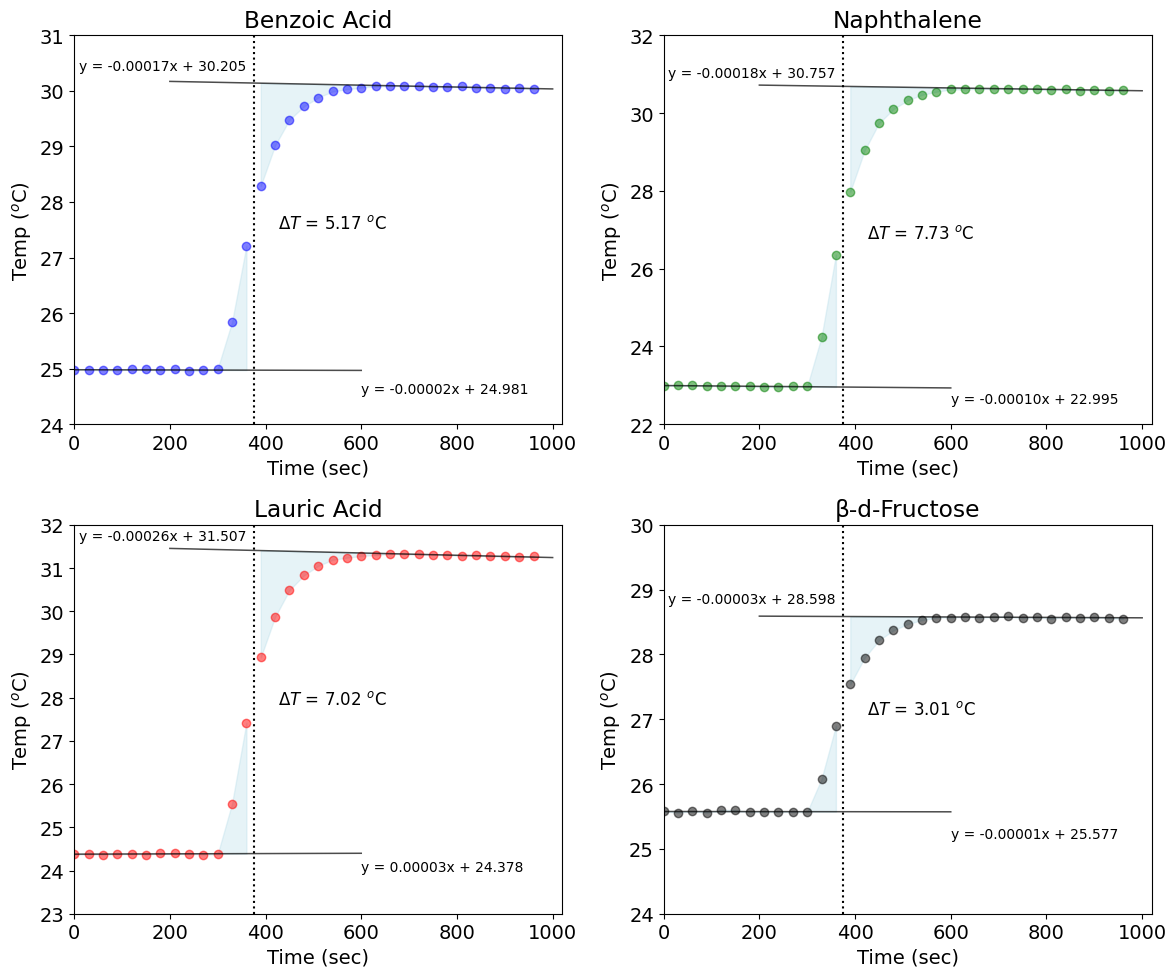

In [ ]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, axes = plt.subplots(2,2, figsize=(12, 10))

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
axes[0,0].plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')
axes[0,1].plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')
axes[1,0].plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Lauric Acid')
axes[1,1].plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines

# Benzoic Acid
axes[0,0].plot(xseq_initial, bi_BA + mi_BA * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[0,0].plot(xseq_final, bf_BA + mf_BA * xseq_final, alpha=0.7, color="k", lw=1.1)

# Naphthalene
axes[0,1].plot(xseq_initial, bi_Naph + mi_Naph * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[0,1].plot(xseq_final, bf_Naph + mf_Naph * xseq_final, alpha=0.7, color="k", lw=1.1)

# Lauric Acid
axes[1,0].plot(xseq_initial, bi_LA + mi_LA * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[1,0].plot(xseq_final, bf_LA + mf_LA * xseq_final, alpha=0.7, color="k", lw=1.1)

# β-d-Fructose
axes[1,1].plot(xseq_initial, bi_BDF + mi_BDF * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[1,1].plot(xseq_final, bf_BDF + mf_BDF * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change

axes[0,0].axvline(x=guess_temp, color='k', linestyle='dotted')
axes[0,1].axvline(x=guess_temp, color='k', linestyle='dotted')
axes[1,0].axvline(x=guess_temp, color='k', linestyle='dotted')
axes[1,1].axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations

# Benzoic Acid
axes[0,0].fill_between(df_BenzoicAcid_3655['Time (s)'],bi_BA + mi_BA * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[0,0].fill_between(df_BenzoicAcid_3655['Time (s)'],bf_BA + mf_BA * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Naphthalene
axes[0,1].fill_between(df_Naphthalene_3655['Time (s)'],bi_Naph + mi_Naph * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[0,1].fill_between(df_Naphthalene_3655['Time (s)'],bf_Naph + mf_Naph * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Lauric Acid
axes[1,0].fill_between(df_LauricAcid_3655['Time (s)'],bi_LA + mi_LA * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[1,0].fill_between(df_LauricAcid_3655['Time (s)'],bf_LA + mf_LA * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# β-d-Fructose
axes[1,1].fill_between(df_b_d_Fructose_3655['Time (s)'],bi_BDF + mi_BDF * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[1,1].fill_between(df_b_d_Fructose_3655['Time (s)'],bf_BDF + mf_BDF * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Annotate ΔT

axes[0,0].text(guess_temp+50, (df_BenzoicAcid_3655['Temperature (C)'].min() + (df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_BA, 2)), fontsize=12)
axes[0,1].text(guess_temp+50, (df_Naphthalene_3655['Temperature (C)'].min() + (df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_Naph, 2)), fontsize=12)
axes[1,0].text(guess_temp+50, (df_LauricAcid_3655['Temperature (C)'].min() + (df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_LA, 2)), fontsize=12)
axes[1,1].text(guess_temp+50, (df_b_d_Fructose_3655['Temperature (C)'].min() + (df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_BDF, 2)), fontsize=12)

# Annotate regression lines with equations

# Benzoic Acid
axes[0,0].annotate(f'y = {mi_BA:.5f}x + {bi_BA:.3f}', xy=(xseq_initial[-1], bi_BA + mi_BA * xseq_initial[-1]), xytext=(600, bi_BA + mi_BA * xseq_initial[-1] - 0.4),fontsize=10)
axes[0,0].annotate(f'y = {mf_BA:.5f}x + {bf_BA:.3f}', xy=(xseq_final[0], bf_BA + mf_BA * xseq_final[0]), xytext=(10, bf_BA + mf_BA * xseq_final[0] + 0.2),fontsize=10)

# Naphthalene
axes[0,1].annotate(f'y = {mi_Naph:.5f}x + {bi_Naph:.3f}', xy=(xseq_initial[-1], bi_Naph + mi_Naph * xseq_initial[-1]), xytext=(600, bi_Naph + mi_Naph * xseq_initial[-1] - 0.4),fontsize=10)
axes[0,1].annotate(f'y = {mf_Naph:.5f}x + {bf_Naph:.3f}', xy=(xseq_final[0], bf_Naph + mf_Naph * xseq_final[0]), xytext=(10, bf_Naph + mf_Naph * xseq_final[0] + 0.2),fontsize=10)

# Lauric Acid
axes[1,0].annotate(f'y = {mi_LA:.5f}x + {bi_LA:.3f}', xy=(xseq_initial[-1], bi_LA + mi_LA * xseq_initial[-1]), xytext=(600, bi_LA + mi_LA * xseq_initial[-1] - 0.4),fontsize=10)
axes[1,0].annotate(f'y = {mf_LA:.5f}x + {bf_LA:.3f}', xy=(xseq_final[0], bf_LA + mf_LA * xseq_final[0]), xytext=(10, bf_LA + mf_LA * xseq_final[0] + 0.2),fontsize=10)

# β-d-Fructose
axes[1,1].annotate(f'y = {mi_BDF:.5f}x + {bi_BDF:.3f}', xy=(xseq_initial[-1], bi_BDF + mi_BDF * xseq_initial[-1]), xytext=(600, bi_BDF + mi_BDF * xseq_initial[-1] - 0.4),fontsize=10)
axes[1,1].annotate(f'y = {mf_BDF:.5f}x + {bf_BDF:.3f}', xy=(xseq_final[0], bf_BDF + mf_BDF * xseq_final[0]), xytext=(10, bf_BDF + mf_BDF * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot

# Benzoic Acid
axes[0,0].set_xlim(0, 1020)
axes[0,0].set_ylim(24, 31)
axes[0,0].set_xlabel("Time (sec)", fontsize=14)
axes[0,0].set_ylabel("Temp ($^o$C)", fontsize=14)

# Naphthalene
axes[0,1].set_xlim(0, 1020)
axes[0,1].set_ylim(22, 32)
axes[0,1].set_xlabel("Time (sec)", fontsize=14)
axes[0,1].set_ylabel("Temp ($^o$C)", fontsize=14)

# Lauric Acid
axes[1,0].set_xlim(0, 1020)
axes[1,0].set_ylim(23, 32)
axes[1,0].set_xlabel("Time (sec)", fontsize=14)
axes[1,0].set_ylabel("Temp ($^o$C)", fontsize=14)

# β-d-Fructose
axes[1,1].set_xlim(0, 1020)
axes[1,1].set_ylim(24, 30)
axes[1,1].set_xlabel("Time (sec)", fontsize=14)
axes[1,1].set_ylabel("Temp ($^o$C)", fontsize=14)

# Add titles to the plots
axes[0,0].set_title('Benzoic Acid')
axes[0,1].set_title('Naphthalene')
axes[1,0].set_title('Lauric Acid')
axes[1,1].set_title('β-d-Fructose')

# Display the plots for easy view (tightly but without losing information)
plt.tight_layout()
plt.show()

In [ ]:
#@title Calculate Calorimeter Constant (Benzoic Acid)
# Heat of Combustion (Benzoic Acid)
H_BA = 26425
# Heat of Combustion (iron wire)
H_FE = 5858
# Weight of Benzoic Acid
W_BA = 1.9730
# Weight of iron wire
W_FE = 0.024-0.018
E_released = (H_BA*W_BA)+(H_FE*W_FE)
C_eq = (E_released/dt_BA)

#Print constant in kJ/K
print('C_eq =', round(C_eq,2), "J/C")

C_eq = 10094.9 J/C


In [ ]:
#@title Horizontal Line Thermodynamic Estimate
C_eq_est = (E_released/dt_BA_est)
print('C_eq_est =', round(C_eq_est,2), "J/C")

C_eq_est = 10169.92 J/C


In [ ]:
#@title Thermodynamic Estimate - Minimum and Maximum
C_eq_est_min = (E_released/dt_BA_min)
C_eq_est_max = (E_released/dt_BA_max)

print('C_eq, min =', round(C_eq_est_min,2), "J/C", " ", 'C_eq, max =', round(C_eq_est_max,2), "J/C")

C_eq, min = 10073.05 J/C   C_eq, max = 10131.53 J/C


In [ ]:
# @title Error Analysis of Calorimetry Constant using Propagation of Error

# Partial derivatives of dt = ((bf + mf * guess_temp) - (bi + mi * guess_temp)):
# d_dt_d_mi = -guess_temp
# d_dt_d_bi = -1
# d_dt_d_mf = guess_temp
# d_dt_d_bf = 1

# Benzoic Acid
d_dt_BA_d_mi_BA = -guess_temp
d_dt_BA_d_bi_BA = -1
d_dt_BA_d_mf_BA = guess_temp
d_dt_BA_d_bf_BA = 1
sigma_dt_BA_squared = (d_dt_BA_d_mi_BA**2 * sigma_mi_BA**2 +
                       d_dt_BA_d_bi_BA**2 * sigma_bi_BA**2 +
                       d_dt_BA_d_mf_BA**2 * sigma_mf_BA**2 +
                       d_dt_BA_d_bf_BA**2 * sigma_bf_BA**2)
sigma_dt_BA = math.sqrt(sigma_dt_BA_squared)


# Error Analysis for C_eq using Propagation of Error
# Uncertainties in the input values:
sigma_H_BA = 132 # Uncertainty in H_BA (J/g)
sigma_W_BA = 0.001 # Uncertainty in W_BA (L)
sigma_H_FE = 59 # Uncertainty in H_FE (J/g)
sigma_W_FE = 0.00002 # Uncertainty in W_FE (g)
# sigma_dt_BA calculated above

# Assuming H_BA, W_BA, H_FE, W_FE, and dt_BA are independent.

# Partial derivatives:
dC_eq_dH_BA = W_BA / dt_BA_est # Units: g / Celsius
dC_eq_dW_BA = H_BA / dt_BA_est # Units: J/(g*Celsius)
dC_eq_dH_FE = W_FE / dt_BA_est # Units: g / Celsius
dC_eq_dW_FE = H_FE / dt_BA_est # Units: J/(g*Celsius)
dC_eq_ddt_BA = -E_released / (dt_BA_est**2) # Units: Joules / Celsius^2

# Square of the error in C_eq:
sigma_C_eq_squared = (dC_eq_dH_BA**2 * sigma_H_BA**2 + # (g^2/Celsius^2) * (J/g)^2 = J^2/Celsius^2
                     dC_eq_dW_BA**2 * sigma_W_BA**2 + # (J^2/(g^2*Celsius^2)) * g^2 = J^2/Celsius^2
                     dC_eq_dH_FE**2 * sigma_H_FE**2 + # (g^2/Celsius^2) * (J/g)^2 = J^2/Celsius^2
                     dC_eq_dW_FE**2 * sigma_W_FE**2 + # (J^2/(g^2*Celsius^2)) * g^2 = J^2/Celsius^2
                     dC_eq_ddt_BA**2 * sigma_dt_BA**2) # (Joules^2 / Celsius^4) * Celsius^2 = Joules^2/Celsius^2

sigma_C_eq = math.sqrt(sigma_C_eq_squared) # Units: J/Celsius

print(f'C_eq = {C_eq:.2f} +/- {sigma_C_eq:.2f} J/Celsius')

C_eq = 10094.90 +/- 83.92 J/Celsius


In [ ]:
# @title Error Analysis of ΔT for Benzoic Acid, Naphthalene, Lauric Acid, and β-d-Fructose using Propagation of Error

# Assuming guess_temp has negligible uncertainty compared to the linear fit parameters.
# Partial derivatives of dt = (bf + mf * guess_temp) - (bi + mi * guess_temp):
# d_dt_d_mi = -guess_temp
# d_dt_d_bi = -1
# d_dt_d_mf = guess_temp
# d_dt_d_bf = 1

# Benzoic Acid
# sigma_dt_BA calculated above

# Naphthalene
d_dt_Naph_d_mi_Naph = -guess_temp
d_dt_Naph_d_bi_Naph = -1
d_dt_Naph_d_mf_Naph = guess_temp
d_dt_Naph_d_bf_Naph = 1
sigma_dt_Naph_squared = (d_dt_Naph_d_mi_Naph**2 * sigma_mi_Naph**2 +
                       d_dt_Naph_d_bi_Naph**2 * sigma_bi_Naph**2 +
                       d_dt_Naph_d_mf_Naph**2 * sigma_mf_Naph**2 +
                       d_dt_Naph_d_bf_Naph**2 * sigma_bf_Naph**2)
sigma_dt_Naph = math.sqrt(sigma_dt_Naph_squared)


# Lauric Acid
d_dt_LA_d_mi_LA = -guess_temp
d_dt_LA_d_bi_LA = -1
d_dt_LA_d_mf_LA = guess_temp
d_dt_LA_d_bf_LA = 1
sigma_dt_LA_squared = (d_dt_LA_d_mi_LA**2 * sigma_mi_LA**2 +
                       d_dt_LA_d_bi_LA**2 * sigma_bi_LA**2 +
                       d_dt_LA_d_mf_LA**2 * sigma_mf_LA**2 +
                       d_dt_LA_d_bf_LA**2 * sigma_bf_LA**2)
sigma_dt_LA = math.sqrt(sigma_dt_LA_squared)


# β-d-Fructose
d_dt_BDF_d_mi_BDF = -guess_temp
d_dt_BDF_d_bi_BDF = -1
d_dt_BDF_d_mf_BDF = guess_temp
d_dt_BDF_d_bf_BDF = 1
sigma_dt_BDF_squared = (d_dt_BDF_d_mi_BDF**2 * sigma_mi_BDF**2 +
                       d_dt_BDF_d_bi_BDF**2 * sigma_bi_BDF**2 +
                       d_dt_BDF_d_mf_BDF**2 * sigma_mf_BDF**2 +
                       d_dt_BDF_d_bf_BDF**2 * sigma_bf_BDF**2)
sigma_dt_BDF = math.sqrt(sigma_dt_BDF_squared)

print(f"Benzoic Acid: Delta T = {dt_BA:.2f} +/- {sigma_dt_BA:.4f} °C")
print(f"Naphthalene: Delta T = {dt_Naph:.2f} +/- {sigma_dt_Naph:.4f} °C")
print(f"Lauric Acid: Delta T = {dt_LA:.2f} +/- {sigma_dt_LA:.4f} °C")
print(f"β-d-Fructose: Delta T = {dt_BDF:.2f} +/- {sigma_dt_BDF:.4f} °C")


Benzoic Acid: Delta T = 5.17 +/- 0.0336 °C
Naphthalene: Delta T = 7.73 +/- 0.0443 °C
Lauric Acid: Delta T = 7.02 +/- 0.0371 °C
β-d-Fructose: Delta T = 3.01 +/- 0.0469 °C


### Enthalpy of Combustion Calculations (J/g)

In [ ]:
# @title
# Calculate Enthalpy of Combustion and Uncertainty for Naphthalene, Lauric Acid, and β-d-Fructose

# Masses and uncertainties of each substance (from Github csv data files)
W_Naph = 1.9483 # Mass of Naphthalene in grams
sigma_W_Naph = 0.0001 # Uncertainty in mass of Naphthalene

W_LA = 1.9233 # Mass of Lauric Acid in grams
sigma_W_LA = 0.0001 # Uncertainty in mass of Lauric Acid

W_BDF = 1.9685 # Mass of β-d-Fructose in grams
sigma_W_BDF = 0.0001 # Uncertainty in mass of β-d-Fructose


# Calculate the enthalpy of combustion for Naphthalene
# Delta_Hc_Naph = -(C_eq * dt_Naph + H_FE * W_FE) / W_Naph

# Error Analysis for Delta Hc for Naphthalene using Propagation of Error
# Partial derivatives:
d_Delta_Hc_Naph_dC_eq = -dt_Naph / W_Naph
d_Delta_Hc_Naph_ddt_Naph = -C_eq / W_Naph
d_Delta_Hc_Naph_dH_FE = -W_FE / W_Naph
d_Delta_Hc_Naph_dW_FE = -H_FE / W_Naph
d_Delta_Hc_Naph_dW_Naph = (C_eq * dt_Naph + H_FE * W_FE) / (W_Naph**2)

# Square of the error in Delta Hc for Naphthalene:
sigma_Delta_Hc_Naph_squared = (d_Delta_Hc_Naph_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_Naph_ddt_Naph**2 * sigma_dt_Naph**2 +
                             d_Delta_Hc_Naph_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_Naph_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_Naph_dW_Naph**2 * sigma_W_Naph**2)

sigma_Delta_Hc_Naph = math.sqrt(sigma_Delta_Hc_Naph_squared)
Delta_Hc_Naph = -(C_eq * dt_Naph + H_FE * W_FE) / W_Naph

print(f'Enthalpy of Combustion for Naphthalene = {Delta_Hc_Naph:.2f} +/- {sigma_Delta_Hc_Naph:.2f} J/g')


# Calculate the enthalpy of combustion for Lauric Acid
# Delta_Hc_LA = -(C_eq * dt_LA + H_FE * W_FE) / W_LA

# Error Analysis for Delta Hc for Lauric Acid using Propagation of Error
# Partial derivatives:
d_Delta_Hc_LA_dC_eq = -dt_LA / W_LA
d_Delta_Hc_LA_ddt_LA = -C_eq / W_LA
d_Delta_Hc_LA_dH_FE = -W_FE / W_LA
d_Delta_Hc_LA_dW_FE = -H_FE / W_LA
d_Delta_Hc_LA_dW_LA = (C_eq * dt_LA + H_FE * W_FE) / (W_LA**2)

# Square of the error in Delta Hc for Lauric Acid:
sigma_Delta_Hc_LA_squared = (d_Delta_Hc_LA_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_LA_ddt_LA**2 * sigma_dt_LA**2 +
                             d_Delta_Hc_LA_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_LA_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_LA_dW_LA**2 * sigma_W_LA**2)

sigma_Delta_Hc_LA = math.sqrt(sigma_Delta_Hc_LA_squared)
Delta_Hc_LA = -(C_eq * dt_LA + H_FE * W_FE) / W_LA

print(f'\nEnthalpy of Combustion for Lauric Acid = {Delta_Hc_LA:.2f} +/- {sigma_Delta_Hc_LA:.2f} J/g')


# Calculate the enthalpy of combustion for β-d-Fructose
# Delta_Hc_BDF = -(C_eq * dt_BDF + H_FE * W_FE) / W_BDF

# Error Analysis for Delta Hc for β-d-Fructose using Propagation of Error
# Partial derivatives:
d_Delta_Hc_BDF_dC_eq = -dt_BDF / W_BDF
d_Delta_Hc_BDF_ddt_BDF = -C_eq / W_BDF
d_Delta_Hc_BDF_dH_FE = -W_FE / W_BDF
d_Delta_Hc_BDF_dW_FE = -H_FE / W_BDF
d_Delta_Hc_BDF_dW_BDF = (C_eq * dt_BDF + H_FE * W_FE) / (W_BDF**2)

# Square of the error in Delta Hc for β-d-Fructose:
sigma_Delta_Hc_BDF_squared = (d_Delta_Hc_BDF_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_BDF_ddt_BDF**2 * sigma_dt_BDF**2 +
                             d_Delta_Hc_BDF_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_BDF_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_BDF_dW_BDF**2 * sigma_W_BDF**2)

sigma_Delta_Hc_BDF = math.sqrt(sigma_Delta_Hc_BDF_squared)
Delta_Hc_BDF = -(C_eq * dt_BDF + H_FE * W_FE) / W_BDF

print(f'\nEnthalpy of Combustion for β-d-Fructose = {Delta_Hc_BDF:.2f} +/- {sigma_Delta_Hc_BDF:.2f} J/g')

Enthalpy of Combustion for Naphthalene = -40081.02 +/- 404.63 J/g

Enthalpy of Combustion for Lauric Acid = -36848.20 +/- 362.89 J/g

Enthalpy of Combustion for β-d-Fructose = -15461.57 +/- 272.55 J/g


### Enthalpy of Combustion Calculations (kJ/mol)

In [ ]:
# @title
# Convert experimental Delta_Hc from J/g to kJ/mol for each substance

# Molar Masses (g/mol): (from Github csv files)
Molar_Mass_BA = 122.113
Molar_Mass_Naph = 128.174
Molar_Mass_LA = 200.311
Molar_Mass_BDF = 180.126

# Experimental enthalpy of combustion (J/g) and their uncertainties:
Delta_Hc_BA_Jg = H_BA
sigma_Delta_Hc_BA_Jg = sigma_H_BA

Delta_Hc_Naph_Jg = Delta_Hc_Naph
sigma_Delta_Hc_Naph_Jg = sigma_Delta_Hc_Naph

Delta_Hc_LA_Jg = Delta_Hc_LA
sigma_Delta_Hc_LA_Jg = sigma_Delta_Hc_LA

Delta_Hc_BDF_Jg = Delta_Hc_BDF
sigma_Delta_Hc_BDF_Jg = sigma_Delta_Hc_BDF


# Convert J/g to kJ/mol and apply the correct sign convention (combustion is exothermic, so Delta Hc is negative)

# Benzoic Acid
Delta_Hc_BA_kJ_mol = -(Delta_Hc_BA_Jg / 1000) * Molar_Mass_BA
sigma_Delta_Hc_BA_kJ_mol = (sigma_Delta_Hc_BA_Jg / 1000) * Molar_Mass_BA
print(f'Benzoic Acid: Delta Hc = {Delta_Hc_BA_kJ_mol:.2f} +/- {sigma_Delta_Hc_BA_kJ_mol:.2f} kJ/mol')

# Naphthalene
Delta_Hc_Naph_kJ_mol = (Delta_Hc_Naph_Jg / 1000) * Molar_Mass_Naph
sigma_Delta_Hc_Naph_kJ_mol = (sigma_Delta_Hc_Naph_Jg / 1000) * Molar_Mass_Naph
print(f'Naphthalene: Delta Hc = {Delta_Hc_Naph_kJ_mol:.2f} +/- {sigma_Delta_Hc_Naph_kJ_mol:.2f} kJ/mol')

# Lauric Acid
Delta_Hc_LA_kJ_mol = (Delta_Hc_LA_Jg / 1000) * Molar_Mass_LA
sigma_Delta_Hc_LA_kJ_mol = (sigma_Delta_Hc_LA_Jg / 1000) * Molar_Mass_LA
print(f'Lauric Acid: Delta Hc = {Delta_Hc_LA_kJ_mol:.2f} +/- {sigma_Delta_Hc_LA_kJ_mol:.2f} kJ/mol')

# β-d-Fructose
Delta_Hc_BDF_kJ_mol = (Delta_Hc_BDF_Jg / 1000) * Molar_Mass_BDF
sigma_Delta_Hc_BDF_kJ_mol = (sigma_Delta_Hc_BDF_Jg / 1000) * Molar_Mass_BDF
print(f'β-d-Fructose: Delta Hc = {Delta_Hc_BDF_kJ_mol:.2f} +/- {sigma_Delta_Hc_BDF_kJ_mol:.2f} kJ/mol')

Benzoic Acid: Delta Hc = -3226.84 +/- 16.12 kJ/mol
Naphthalene: Delta Hc = -5137.34 +/- 51.86 kJ/mol
Lauric Acid: Delta Hc = -7381.10 +/- 72.69 kJ/mol
β-d-Fructose: Delta Hc = -2785.03 +/- 49.09 kJ/mol


### Enthalpy of Formation Calculations

#### Combustion Chemical Equations

Here are the balanced chemical equations for the combustion of each substance:

*   **Benzoic Acid (C7H6O2):** C7H6O2(s) + 7.5 O2(g) -> 7 CO2(g) + 3 H2O(l)
*   **Naphthalene (C10H8):** C10H8(s) + 12 O2(g) -> 10 CO2(g) + 4 H2O(l)
*   **Lauric Acid (C12H24O2):** C12H24O2(s) + 17 O2(g) -> 12 CO2(g) + 12 H2O(l)
*   **β-d-Fructose (C6H12O6):** C6H12O6(s) + 6 O2(g) -> 6 CO2(g) + 6 H2O(l)

In [ ]:
# @title Calculation of Enthalpy of Formation (Delta_Hf) using Hess's Law

# Standard Enthalpies of Formation (kJ/mol) and their uncertainties
Delta_Hf_CO2_g = -393.51 # from NIST Webbook
sigma_Delta_Hf_CO2_g = 0.13

Delta_Hf_H2O_l = -285.83 # from NIST Webbook
sigma_Delta_Hf_H2O_l = 0.04

Delta_Hf_O2_g = 0.0 # Standard state element
sigma_Delta_Hf_O2_g = 0.0

# Literature value for the enthalpy of sublimation of Naphthalene (solid to gas)
Delta_H_sub_Naph = Delta_H_sub_Naph_lit
sigma_Delta_H_sub_Naph = sigma_Delta_H_sub_Naph_lit


# Chemical equations for the combustion of each substance:
# Benzoic Acid (C7H6O2): C7H6O2(s) + 7.5 O2(g) -> 7 CO2(g) + 3 H2O(l)
# Naphthalene (C10H8): C10H8(s) + 12 O2(g) -> 10 CO2(g) + 4 H2O(l)
# Lauric Acid (C12H24O2): C12H24O2(s) + 17 O2(g) -> 12 CO2(g) + 12 H2O(l)
# β-d-Fructose (C6H12O6): C6H12O6(s) + 6 O2(g) -> 6 CO2(g) + 6 H2O(l)

# Hess's Law: Delta_Hc = Sum(n * Delta_Hf_products) - Sum(m * Delta_Hf_reactants)
# Rearranging to find Delta_Hf_reactant:
# Delta_Hf_reactant = Sum(n * Delta_Hf_products) - Delta_Hc - Sum(m * Delta_Hf_other_reactants)

# Molar Masses (g/mol):
# Molar_Mass_BA = 122.113
# Molar_Mass_Naph = 128.174
# Molar_Mass_LA = 200.311
# Molar_Mass_BDF = 180.126

# Experimental enthalpy of combustion (J/g) and their uncertainties (recalculated to better distinguish in further calculations between variables in J/mol and kJ/mol):

# Delta_Hc_BA_Jg = H_BA (# 26425)
# sigma_Delta_Hc_BA_Jg = sigma_H_BA (# 132)

# Masses and uncertainties of each substance

# W_Naph = 1.9483 # Mass of Naphthalene in grams
# sigma_W_Naph = 0.0001 # Uncertainty in mass of Naphthalene
# W_LA = 1.9233 # Mass of Lauric Acid in grams
# sigma_W_LA = 0.0001 # Uncertainty in mass of Lauric Acid
# W_BDF = 1.9685 # Mass of β-d-Fructose in grams
# sigma_W_BDF = 0.0001 # Uncertainty in mass of β-d-Fructose
# H_FE = 5858
# sigma_H_FE = 59 # Uncertainty in Hfe (J/g)
# W_FE = 0.024-0.018
# sigma_W_FE = 0.00002 # Uncertainty in Wfe (g)

# Calculate Ceq and its uncertainty
# C_eq = E_released/dt_BA # Use the pre-calculated C_eq and sigma_C_eq from earlier cells


# Calculate the enthalpy of combustion for Naphthalene (J/g)
Delta_Hc_Naph_jg = -(C_eq * dt_Naph + H_FE * W_FE) / W_Naph

# Error Analysis for Delta Hc for Naphthalene (J/g) using Propagation of Error
# Partial derivatives:
d_Delta_Hc_Naph_dC_eq = -dt_Naph / W_Naph
d_Delta_Hc_Naph_ddt_Naph = -C_eq / W_Naph
d_Delta_Hc_Naph_dH_FE = -W_FE / W_Naph
d_Delta_Hc_Naph_dW_FE = -H_FE / W_Naph
d_Delta_Hc_Naph_dW_Naph = (C_eq * dt_Naph + H_FE * W_FE) / (W_Naph**2)

# Square of the error in Delta Hc for Naphthalene:
sigma_Delta_Hc_Naph_jg_squared = (d_Delta_Hc_Naph_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_Naph_ddt_Naph**2 * sigma_dt_Naph**2 +
                             d_Delta_Hc_Naph_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_Naph_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_Naph_dW_Naph**2 * sigma_W_Naph**2)

sigma_Delta_Hc_Naph_jg = math.sqrt(sigma_Delta_Hc_Naph_jg_squared)


# Calculate the enthalpy of combustion for Lauric Acid (J/g)
Delta_Hc_LA_jg = -(C_eq * dt_LA + H_FE * W_FE) / W_LA

# Error Analysis for Delta Hc for Lauric Acid (J/g) using Propagation of Error
# Partial derivatives:
d_Delta_Hc_LA_dC_eq = -dt_LA / W_LA
d_Delta_Hc_LA_ddt_LA = -C_eq / W_LA
d_Delta_Hc_LA_dH_FE = -W_FE / W_LA
d_Delta_Hc_LA_dW_FE = -H_FE / W_LA
d_Delta_Hc_LA_dW_LA = (C_eq * dt_LA + H_FE * W_FE) / (W_LA**2)

# Square of the error in Delta Hc for Lauric Acid:
sigma_Delta_Hc_LA_jg_squared = (d_Delta_Hc_LA_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_LA_ddt_LA**2 * sigma_dt_LA**2 +
                             d_Delta_Hc_LA_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_LA_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_LA_dW_LA**2 * sigma_W_LA**2)

sigma_Delta_Hc_LA_jg = math.sqrt(sigma_Delta_Hc_LA_jg_squared)


# Calculate the enthalpy of combustion for β-d-Fructose (J/g)
Delta_Hc_BDF_jg = -(C_eq * dt_BDF + H_FE * W_FE) / W_BDF

# Error Analysis for Delta Hc for β-d-Fructose (J/g) using Propagation of Error
# Partial derivatives:
d_Delta_Hc_BDF_dC_eq = -dt_BDF / W_BDF
d_Delta_Hc_BDF_ddt_BDF = -C_eq / W_BDF
d_Delta_Hc_BDF_dH_FE = -W_FE / W_BDF
d_Delta_Hc_BDF_dW_FE = -H_FE / W_BDF
d_Delta_Hc_BDF_dW_BDF = (C_eq * dt_BDF + H_FE * W_FE) / (W_BDF**2)

# Square of the error in Delta Hc for β-d-Fructose:
sigma_Delta_Hc_BDF_jg_squared = (d_Delta_Hc_BDF_dC_eq**2 * sigma_C_eq**2 +
                             d_Delta_Hc_BDF_ddt_BDF**2 * sigma_dt_BDF**2 +
                             d_Delta_Hc_BDF_dH_FE**2 * sigma_H_FE**2 +
                             d_Delta_Hc_BDF_dW_FE**2 * sigma_W_FE**2 +
                             d_Delta_Hc_BDF_dW_BDF**2 * sigma_W_BDF**2)

sigma_Delta_Hc_BDF_jg = math.sqrt(sigma_Delta_Hc_BDF_jg_squared)


# Convert J/g to kJ/mol and apply the correct sign convention (combustion is exothermic, so Delta Hc is negative)
print("Enthalpies of Combustion:")

# Benzoic Acid
Delta_Hc_BA_kj_mol = -(Delta_Hc_BA_Jg / 1000) * Molar_Mass_BA
sigma_Delta_Hc_BA_kj_mol = (sigma_Delta_Hc_BA_Jg / 1000) * Molar_Mass_BA
print(f'Benzoic Acid: Delta Hc = {Delta_Hc_BA_kj_mol:.2f} +/- {sigma_Delta_Hc_BA_kj_mol:.2f} kJ/mol')

# Naphthalene
Delta_Hc_Naph_kj_mol = (Delta_Hc_Naph_jg / 1000) * Molar_Mass_Naph
sigma_Delta_Hc_Naph_kj_mol = (sigma_Delta_Hc_Naph_jg / 1000) * Molar_Mass_Naph
print(f'Naphthalene: Delta Hc = {Delta_Hc_Naph_kj_mol:.2f} +/- {sigma_Delta_Hc_Naph_kj_mol:.2f} kJ/mol')

# Lauric Acid
Delta_Hc_LA_kj_mol = (Delta_Hc_LA_jg / 1000) * Molar_Mass_LA
sigma_Delta_Hc_LA_kj_mol = (sigma_Delta_Hc_LA_jg / 1000) * Molar_Mass_LA
print(f'Lauric Acid: Delta Hc = {Delta_Hc_LA_kj_mol:.2f} +/- {sigma_Delta_Hc_LA_kj_mol:.2f} kJ/mol')

# β-d-Fructose
Delta_Hc_BDF_kj_mol = (Delta_Hc_BDF_jg / 1000) * Molar_Mass_BDF
sigma_Delta_Hc_BDF_kj_mol = (sigma_Delta_Hc_BDF_jg / 1000) * Molar_Mass_BDF
print(f'β-d-Fructose: Delta Hc = {Delta_Hc_BDF_kj_mol:.2f} +/- {sigma_Delta_Hc_BDF_kj_mol:.2f} kJ/mol')

#Calculate Enthalpies of Formation
print("")
print("Enthalpies of Formation:")

# Benzoic Acid (C7H6O2)
# Delta_Hf_C7H6O2 = (7 * Delta_Hf_CO2_g + 3 * Delta_Hf_H2O_l) - Delta_Hc_BA_kj_mol - (7.5 * Delta_Hf_O2_g)
Delta_Hf_BA = -((7 * Delta_Hf_CO2_g + 3 * Delta_Hf_H2O_l) - Delta_Hc_BA_kj_mol - (7.5 * Delta_Hf_O2_g))

# Error Propagation for Benzoic Acid Delta_Hf
# Partial derivatives:
d_Delta_Hf_BA_d_Delta_Hf_CO2_g = 7
d_Delta_Hf_BA_d_Delta_Hf_H2O_l = 3
d_Delta_Hf_BA_d_Delta_Hc_BA_kj_mol = -1
d_Delta_Hf_BA_d_Delta_Hf_O2_g = -7.5

# Assuming uncertainties in Delta_Hf_CO2, Delta_Hf_H2O, Delta_Hc_BA, and Delta_Hf_O2 are independent
sigma_Delta_Hf_BA_squared = (d_Delta_Hf_BA_d_Delta_Hf_CO2_g**2 * sigma_Delta_Hf_CO2_g**2 +
                             d_Delta_Hf_BA_d_Delta_Hf_H2O_l**2 * sigma_Delta_Hf_H2O_l**2 +
                             d_Delta_Hf_BA_d_Delta_Hc_BA_kj_mol**2 * sigma_Delta_Hc_BA_kj_mol**2 +
                             d_Delta_Hf_BA_d_Delta_Hf_O2_g**2 * sigma_Delta_Hf_O2_g**2)

sigma_Delta_Hf_BA = math.sqrt(sigma_Delta_Hf_BA_squared)
print(f'Benzoic Acid (solid): Delta Hf = {Delta_Hf_BA:.2f} +/- {sigma_Delta_Hf_BA:.2f} kJ/mol')


# Naphthalene (C10H8) - Solid
# Delta_Hf_C10H8(s) = (10 * Delta_Hf_CO2_g + 4 * Delta_Hf_H2O_l) - Delta_Hc_Naph_kj_mol - (12 * Delta_Hf_O2_g)
Delta_Hf_Naph = (10 * Delta_Hf_CO2_g + 4 * Delta_Hf_H2O_l) - Delta_Hc_Naph_kj_mol - (12 * Delta_Hf_O2_g)

# Error Propagation for Naphthalene Delta_Hf (solid)
# Partial derivatives:
d_Delta_Hf_Naph_d_Delta_Hf_CO2_g = 10
d_Delta_Hf_Naph_d_Delta_Hf_H2O_l = 4
d_Delta_Hf_Naph_d_Delta_Hc_Naph_kj_mol = -1
d_Delta_Hf_Naph_d_Delta_Hf_O2_g = -12


# Assuming uncertainties are independent
sigma_Delta_Hf_Naph_squared = (d_Delta_Hf_Naph_d_Delta_Hf_CO2_g**2 * sigma_Delta_Hf_CO2_g**2 +
                                   d_Delta_Hf_Naph_d_Delta_Hf_H2O_l**2 * sigma_Delta_Hf_H2O_l**2 +
                                   d_Delta_Hf_Naph_d_Delta_Hc_Naph_kj_mol**2 * sigma_Delta_Hc_Naph_kj_mol**2 +
                                   d_Delta_Hf_Naph_d_Delta_Hf_O2_g**2 * sigma_Delta_Hf_O2_g**2)

sigma_Delta_Hf_Naph = math.sqrt(sigma_Delta_Hf_Naph_squared)
print(f'Naphthalene (solid): Delta Hf = {Delta_Hf_Naph:.2f} +/- {sigma_Delta_Hf_Naph:.2f} kJ/mol')


# Lauric Acid (C12H24O2)
# Delta_Hf_C12H24O2 = (12 * Delta_Hf_CO2_g + 12 * Delta_Hf_H2O_l) - Delta_Hc_LA_kj_mol - (17 * Delta_Hf_O2_g)
Delta_Hf_LA = (12 * Delta_Hf_CO2_g + 12 * Delta_Hf_H2O_l) - Delta_Hc_LA_kj_mol - (17 * Delta_Hf_O2_g)

# Error Propagation for Lauric Acid Delta_Hf
# Partial derivatives:
d_Delta_Hf_LA_d_Delta_Hf_CO2_g = 12
d_Delta_Hf_LA_d_Delta_Hf_H2O_l = 12
d_Delta_Hf_LA_d_Delta_Hc_LA_kj_mol = -1
d_Delta_Hf_LA_d_Delta_Hf_O2_g = -17

# Assuming uncertainties are independent
sigma_Delta_Hf_LA_squared = (d_Delta_Hf_LA_d_Delta_Hf_CO2_g**2 * sigma_Delta_Hf_CO2_g**2 +
                             d_Delta_Hf_LA_d_Delta_Hf_H2O_l**2 * sigma_Delta_Hf_H2O_l**2 +
                             d_Delta_Hf_LA_d_Delta_Hc_LA_kj_mol**2 * sigma_Delta_Hc_LA_kj_mol**2 +
                             d_Delta_Hf_LA_d_Delta_Hf_O2_g**2 * sigma_Delta_Hf_O2_g**2)

sigma_Delta_Hf_LA = math.sqrt(sigma_Delta_Hf_LA_squared)
print(f'Lauric Acid (solid): Delta Hf = {Delta_Hf_LA:.2f} +/- {sigma_Delta_Hf_LA:.2f} kJ/mol')


# β-d-Fructose (C6H12O6)
# Delta_Hf_C6H12O6 = (6 * Delta_Hf_CO2_g + 6 * Delta_Hf_H2O_l) - Delta_Hc_BDF_kj_mol - (6 * Delta_Hf_O2_g)
Delta_Hf_BDF = (6 * Delta_Hf_CO2_g + 6 * Delta_Hf_H2O_l) - Delta_Hc_BDF_kj_mol - (6 * Delta_Hf_O2_g)

# Error Propagation for β-d-Fructose Delta_Hf
# Partial derivatives:
d_Delta_Hf_BDF_d_Delta_Hf_CO2_g = 6
d_Delta_Hf_BDF_d_Delta_Hf_H2O_l = 6
d_Delta_Hf_BDF_d_Delta_Hc_BDF_kj_mol = -1
d_Delta_Hf_BDF_d_Delta_Hf_O2_g = -6

# Assuming uncertainties are independent
sigma_Delta_Hf_BDF_squared = (d_Delta_Hf_BDF_d_Delta_Hf_CO2_g**2 * sigma_Delta_Hf_CO2_g**2 +
                             d_Delta_Hf_BDF_d_Delta_Hf_H2O_l**2 * sigma_Delta_Hf_H2O_l**2 +
                             d_Delta_Hf_BDF_d_Delta_Hc_BDF_kj_mol**2 * sigma_Delta_Hc_BDF_kj_mol**2 +
                             d_Delta_Hf_BDF_d_Delta_Hf_O2_g**2 * sigma_Delta_Hf_O2_g**2)

sigma_Delta_Hf_BDF = math.sqrt(sigma_Delta_Hf_BDF_squared)
print(f'β-d-Fructose (solid): Delta Hf = {Delta_Hf_BDF:.2f} +/- {sigma_Delta_Hf_BDF:.2f} kJ/mol')

Enthalpies of Combustion:
Benzoic Acid: Delta Hc = -3226.84 +/- 16.12 kJ/mol
Naphthalene: Delta Hc = -5137.34 +/- 51.86 kJ/mol
Lauric Acid: Delta Hc = -7381.10 +/- 72.69 kJ/mol
β-d-Fructose: Delta Hc = -2785.03 +/- 49.09 kJ/mol

Enthalpies of Formation:
Benzoic Acid (solid): Delta Hf = 385.22 +/- 16.15 kJ/mol
Naphthalene (solid): Delta Hf = 58.92 +/- 51.88 kJ/mol
Lauric Acid (solid): Delta Hf = -770.98 +/- 72.71 kJ/mol
β-d-Fructose (solid): Delta Hf = -1291.01 +/- 49.10 kJ/mol


In [ ]:
# Create a table to compare computational and experimental enthalpy values

data = {
    'Substance': ['Benzoic Acid', 'Naphthalene', 'Lauric Acid', 'β-d-Fructose'],
    'Computational Delta Hf (Solid, kJ/mol)': [
        f'{Delta_Hf_BA_solid:.2f} +/- {sigma_Delta_Hf_BA_solid:.2f}',
        f'{Delta_Hf_Naph_solid:.2f} +/- {sigma_Delta_Hf_Naph_solid:.2f}',
        f'{Delta_Hf_LA_solid:.2f} +/- {sigma_Delta_Hf_LA_solid:.2f}',
        f'{Delta_Hf_BDF_solid:.2f} +/- {sigma_Delta_Hf_BDF_solid:.2f}'
    ],
    'Computational Delta Hc (Solid, kJ/mol)': [
        f'{Delta_Hc_BA_calc:.2f} +/- {sigma_Delta_Hc_BA_calc:.2f}',
        f'{Delta_Hc_Naph_calc:.2f} +/- {sigma_Delta_Hc_Naph_calc:.2f}',
        f'{Delta_Hc_LA_calc:.2f} +/- {sigma_Delta_Hc_LA_calc:.2f}',
        f'{Delta_Hc_BDF_calc:.2f} +/- {sigma_Delta_Hc_BDF_calc:.2f}'
    ],
    'Experimental Delta Hf (Solid, kJ/mol)': [
        f'{Delta_Hf_BA:.2f} +/- {sigma_Delta_Hf_BA:.2f}',
        f'{Delta_Hf_Naph:.2f} +/- {sigma_Delta_Hf_Naph:.2f}',
        f'{Delta_Hf_LA:.2f} +/- {sigma_Delta_Hf_LA:.2f}',
        f'{Delta_Hf_BDF:.2f} +/- {sigma_Delta_Hf_BDF:.2f}'
    ],
    'Experimental Delta Hc (Solid, kJ/mol)': [
        f'{Delta_Hc_BA_kj_mol:.2f} +/- {sigma_Delta_Hc_BA_kj_mol:.2f}',
        f'{Delta_Hc_Naph_kj_mol:.2f} +/- {sigma_Delta_Hc_Naph_kj_mol:.2f}',
        f'{Delta_Hc_LA_kj_mol:.2f} +/- {sigma_Delta_Hc_LA_kj_mol:.2f}',
        f'{Delta_Hc_BDF_kj_mol:.2f} +/- {sigma_Delta_Hc_BDF_kj_mol:.2f}'
    ],
    'Literature Delta Hf Values (Solid, kJ/mol) (NIST WebBook)': [
        '384.8 +/- 0.50', # Placeholder for Benzoic Acid Literature Delta Hf
        '77 +/- 10', # Placeholder for Naphthalene Literature Delta Hf
        '-775', # Placeholder for Lauric Acid Literature Delta Hf
        '-1265.6 +/- 0.46'  # Placeholder for β-d-Fructose Literature Delta Hf
    ],
    'Literature Delta Hc Values (Solid, kJ/mol) (NIST WebBook)': [
        '-3228 +/- 4', # Placeholder for Benzoic Acid Literature Delta Hc
        '-5160 +/- 20', # Placeholder for Naphthalene Literature Delta Hc
        '-7423.7 +/- 7.5', # Placeholder for Lauric Acid Literature Delta Hc
        '-2810.4 +/- 0.3'  # Placeholder for β-d-Fructose Literature Delta Hc
    ]
}

# Reorder the columns in the data dictionary before creating the DataFrame
ordered_keys = [
    'Substance',
    'Computational Delta Hf (Solid, kJ/mol)',
    'Computational Delta Hc (Solid, kJ/mol)',
    'Experimental Delta Hf (Solid, kJ/mol)',
    'Experimental Delta Hc (Solid, kJ/mol)',
    'Literature Delta Hf Values (Solid, kJ/mol) (NIST WebBook)',
    'Literature Delta Hc Values (Solid, kJ/mol) (NIST WebBook)'
]

ordered_data = {key: data[key] for key in ordered_keys}

df_comparison_summary = pd.DataFrame(ordered_data)

# Apply styling to the DataFrame
styled_comparison_df = df_comparison_summary.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('background-color', 'steelblue'), ('color', 'white')]}])

display(styled_comparison_df.hide(axis='index'))

Substance,"Computational Delta Hf (Solid, kJ/mol)","Computational Delta Hc (Solid, kJ/mol)","Experimental Delta Hf (Solid, kJ/mol)","Experimental Delta Hc (Solid, kJ/mol)","Literature Delta Hf Values (Solid, kJ/mol) (NIST WebBook)","Literature Delta Hc Values (Solid, kJ/mol) (NIST WebBook)"
Benzoic Acid,363.21 +/- 4.00,-3649.84 +/- 4.00,385.22 +/- 16.15,-3226.84 +/- 16.12,384.8 +/- 0.50,-3228 +/- 4
Naphthalene,104.42 +/- 0.50,-4723.08 +/- 0.50,58.92 +/- 51.88,-5137.34 +/- 51.86,77 +/- 10,-5160 +/- 20
Lauric Acid,-731.48 +/- 3.00,-6739.36 +/- 3.00,-770.98 +/- 72.71,-7381.10 +/- 72.69,-775,-7423.7 +/- 7.5
β-d-Fructose,-1265.60 +/- 0.46,-2469.82 +/- 0.46,-1291.01 +/- 49.10,-2785.03 +/- 49.09,-1265.6 +/- 0.46,-2810.4 +/- 0.3


# **Discussion**

# **Acknowledgements**

# **References**

[1] MoleCalc.Cloud. https://molecalc.cloud/.

[2] gamess | ChemCompute: Free Computational Chemistry For Undergraduates. https://chemcompute.org/gamess.

[3] Yarger Research Group at ASU. Bomb Calorimetry Simulator. Bomb Calorimetry Simulator. https://asu-molecular-sciences-cloud-lab.github.io/bomb_calorimetry_v2/#/.

[4] Biology LibreTexts. 2.13: Water - Heat of Vaporization. https://bio.libretexts.org/Bookshelves/Introductory_and_General_Biology/General_Biology_(Boundless)/02%3A_The_Chemical_Foundation_of_Life/2.13%3A_Water_-_Heat_of_Vaporization (accessed 2025-09-25).

[5] NIST Webbook. Benzoic Acid. https://webbook.nist.gov/cgi/cbook.cgi?ID=C65850&Mask=4 (accessed 2025-09-23).

[6] Arizona State University. Benzoic Acid PM6 Thermochemical Properties. MoleCalc.Cloud. https://molecalc.cloud/calculations/da5d1d14cc9d696aa0668bdbd3fe099d (accessed 2025-09-23).

[7] ChemCompute GAMESS. Beta-d-Fructose PM6 Thermochemical Properties. https://chemcompute.org/gamess/status/1265099 (accessed 2025-09-24).

[8] Yarger Research Group at ASU. Bomb Calorimetry Simulator - Constants. Bomb Calorimetry Simulator. https://asu-molecular-sciences-cloud-lab.github.io/bomb_calorimetry_v2/#/constants (accessed 2025-09-26).

[9] Yarger Research Group at ASU. Bomb Calorimetry Simulator - Discussion. https://asu-molecular-sciences-cloud-lab.github.io/bomb_calorimetry_v2/#/discussion (accessed 2025-09-26).

[10] Yarger Research Group at ASU. Bomb Calorimetry Simulator - Instructions. Bomb Calorimetry Simulator. https://asu-molecular-sciences-cloud-lab.github.io/bomb_calorimetry_v2/#/instructions (accessed 2025-09-26).

[11] NIST Webbook. Carbon Dioxide. https://webbook.nist.gov/cgi/cbook.cgi?ID=C124389&Mask=1 (accessed 2025-09-26).

[12] Arizona State University. Carbon Dioxide PM6 Thermochemical Properties. MoleCalc.Cloud. https://molecalc.cloud/calculations/ede29015de9b5d5bf74fc3d05d3e6d6f (accessed 2025-09-25).

[13] NIST Webbook. Dodecanoic (Lauric) Acid. https://webbook.nist.gov/cgi/inchi?ID=C143077&Mask=4 (accessed 2025-09-24).

[14] Arizona State University. Dodecanoic (Lauric) Acid PM6 Thermochemical Properties. MoleCalc.Cloud. https://molecalc.cloud/calculations/7a66d5d4bd72126007c22b5cd60248e6 (accessed 2025-09-24).

[15] NIST Webbook. Fructose. https://webbook.nist.gov/cgi/cbook.cgi?ID=C57487&Mask=2 (accessed 2025-09-24).

[16] Jeffery L. Yarger. Introduction to Bomb Calorimetry Simulator & Thermochemistry. Physical Chemistry Cloud Laboratory on Vimeo. https://vimeo.com/showcase/11848054 (accessed 2025-09-20).

[17] Jeffery L. Yarger. Introduction to Molecular Thermochemistry. Physical Chemistry Cloud Laboratory on Vimeo. https://vimeo.com/showcase/11848054 (accessed 2025-09-20).

[18] PubChem. Lauric Acid - Heat of Formation. https://pubchem.ncbi.nlm.nih.gov/compound/3893 (accessed 2025-09-26).

[19] Jeffery L. Yarger. Molecular Thermochemistry - Calorimetry - Live Demo. Physical Chemistry Cloud Laboratory on Vimeo. https://vimeo.com/showcase/11848054 (accessed 2025-09-20).

[20] NIST Webbook. Naphthalene. https://webbook.nist.gov/cgi/cbook.cgi?ID=C91203&Mask=4 (accessed 2025-09-23).

[21] Arizona State University. Naphthalene PM6 Thermochemical Properties. MoleCalc.Cloud. https://molecalc.cloud/calculations/a58e24dfb295dae96f87882517e34940 (accessed 2025-09-23).

[22] Informatics, N. O. of D. and. NIST Chemistry WebBook. https://webbook.nist.gov/chemistry/ (accessed 2025-09-27).

[23] Maraschin, M.; Lanzanova, T. D. M.; Salau, N. P. G. Predictions of Heat of Combustion and Formation by Interpretable Machine Learning Algorithms. Fuel 2025, 390, 134699. https://doi.org/10.1016/j.fuel.2025.134699.

[24] Churney, K. L.; Armstrong, G. T. Studies in Bomb Calorimetry. A New Determination of the Energy of Combustion of Benzoic Acid in Terms of Electrical Units. Journal of research of the National Bureau of Standards. Section A. Physics and chemistry 1968, 72A (5), 453–465.

[25] NIST Webbook. Water. https://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=2 (accessed 2025-09-26).

[26] Arizona State University. Water PM6 Thermochemical Properties. MoleCalc.Cloud. https://molecalc.cloud/calculations/f7d7fcebde498f3b335400ea95ad7007 (accessed 2025-09-25).


